# **CASO 3 — CREDIT RISK SCORING (FINANZAS)**



**Integrantes del grupo:**


*   Ivonne Micaela Colque Murillo
*   Adriana Nathalie Rocha Vedia

*   Tania Morelia Pérez Dick
*   Ignacio Retamozo Torrez
*   Dilan Obed Mamani Pamuri

**Link de dataset:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


Falat poner entendimiento del negocioooo problema y objetivos

# **1. Cargado de Librerias y Dataset**

In [ ]:
import sys

assert sys.version_info >= (3, 7)

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [ ]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)

import numpy as np

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn import preprocessing
from scipy import stats
from pandas import Series, DataFrame
from pandas.plotting import autocorrelation_plot
#from pandas.tools.plotting import scatter_matrix
from pylab import rcParams
from matplotlib import collections as collections
from matplotlib.patches import Rectangle
from itertools import cycle

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings('ignore')

rcParams['figure.figsize'] = 5,4
#sb.set_style('whitegrid')
from numpy import median
from numpy import mean

#Semilla
np.random.seed(42)

**NOTA:** Se procede a hacer la preparación del entorno, la importación de las libreriías y asignar una semilla, ello con el fin de hacer que el modelo sea reprocucible.

In [ ]:
import zipfile
import urllib.request
from pathlib import Path

URL_DATOS = "https://archive.ics.uci.edu/static/public/350/default%2Bof%2Bcredit%2Bcard%2Bclients.zip"

def cargar_datos_credito(ruta_base: str | Path = "datasets") -> pd.DataFrame:
    ruta_base = Path(ruta_base)
    ruta_zip = ruta_base / "credit_risk.zip"
    ruta_extraida = ruta_base / "credit_risk"

    # 1) Descargar si no existe
    if not ruta_zip.is_file():
        ruta_base.mkdir(parents=True, exist_ok=True)
        print("Descargando datos desde UCI...")
        urllib.request.urlretrieve(URL_DATOS, ruta_zip)
        print("Descarga completada.")

    # 2) Extraer si no existe la carpeta extraída
    if not ruta_extraida.is_dir():
        print("Extrayendo archivos...")
        with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
            zip_ref.extractall(ruta_extraida)
        print("Extracción completada.")
        # Ver qué archivos se extrajeron
        archivos = list(ruta_extraida.rglob("*"))
        print(f"Archivos encontrados: {[a.name for a in archivos]}")

    # 3) Buscar y cargar el XLS/XLSX (UCI lo entrega en Excel)
    archivos_excel = list(ruta_extraida.rglob("*.xls*"))
    if not archivos_excel:
        raise FileNotFoundError(f"No se encontró archivo Excel en {ruta_extraida}")

    ruta_excel = archivos_excel[0]
    print(f"Cargando: {ruta_excel.name}")

    # El dataset tiene la fila 0 como descripción y fila 1 como header real
    df = pd.read_excel(ruta_excel, header=1)

    # 4) Limpieza básica de nombres de columnas
    df.columns = df.columns.str.strip()

    # Renombrar columna target para facilidad de uso
    if 'default payment next month' in df.columns:
        df = df.rename(columns={'default payment next month': 'default'})

    return df

df = cargar_datos_credito()

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Descargando datos desde UCI...
Descarga completada.
Extrayendo archivos...
Extracción completada.
Archivos encontrados: ['default of credit card clients.xls']
Cargando: default of credit card clients.xls

Dimensiones del dataset: (30000, 25)
Filas: 30,000 | Columnas: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**NOTA: **Se procede a verificar si es que el dataset fue cargado de manera correcta. Como se puede evidenciar el dataset fue cargado de manera correcta mostrandose así que este cuenta con 30000 filas y 25 features o columnas.

# **2. EDA**

## **2.1. Conteo de variables objetivo**

### **Regresión**

In [ ]:
df['PAY_AMT1'].value_counts()

**NOTA:** Se procede a hacer el conteo de los valores del target de regresión, en este caso el target PAY_AMT1 presenta 7943 valores únicos, lo que confirma su naturaleza continua y la adecuación de un modelo de regresión. Asimismo, como se puede evidenciar existen 5249 registros que tiene el valor de 0, lo que representa que esa cantidad de clientes no realizaron ningún pago ese mes. Esa concentración de ceros sugiere una distribución fuertemente sesgada a la derecha, lo que nos servirá mas adelante para analizar la distribución de esa variable.

### **Clasificación**

In [ ]:
df['default'].value_counts()

**NOTA:** Se procede a hacer el conteo de los valores del target de clasificación, en este caso el target default puede tomar dos valores: 0 (no default) y 1 (default). Como se puede evidenciar se encuentra desbalanceado, es decir, 23364 clientes no entraron en default lo que equivale al 77.9% y 6636 si lo hicieron, el 22.1%. Esta diferencia significativa entre clases sugiere que el modelo podría tender a favorecer a la clase mayoritaria.

## **2.2. Información del Dataset**

In [ ]:
df.head()

**NOTA:** Se visualizan los primeros 5 registros del dataset para tener una primera impresión de la estructura de los datos, los tipos de variables y los valores que toman. Asimismo, se puede observar que el dataset contiene variables numéricas enteras
correspondientes a montos de pago, estados de cuenta y características demográficas del cliente.

In [ ]:
df.shape

**NOTA:** Como se puede evidenciar, el dataset cuenta con 30,000 registros y 25 features (incluyendo las variables objetivo o los targets). Esto representa una muestra suficientemente grande para entrenar modelos de clasificación y regresión.

In [ ]:
df.info()

**NOTA:** Todas las variables son de tipo entero , lo que indica que no existen variables categóricas. Sin embargo, variables como SEX,
EDUCATION, MARRIAGE y PAY_0 a PAY_6 son categóricas codificadas numéricamente o mapeadas.

In [ ]:
df.describe()

**NOTA:** Se analizan las estadísticas descriptivas de las variables numéricas continuas.
Se destacan los siguientes puntos:
- ***LIMIT_BAL***: el límite de crédito varía entre 10,000 y 1,000,000 NTS, con una media de 167484 NTS, lo que sugiere alta variabilidad entre clientes.
- ***BILL_AMT1 a BILL_AMT6***: presentan valores negativos, lo que corresponde a créditos a favor del cliente (pagos en exceso). Esto es válido y no representa un error en los datos.
- ***PAY_AMT1 a PAY_AMT6***: presentan una distribución fuertemente sesgada a la derecha, con valores mínimos de 0 (sin pago) y máximos que superan los 800000 NTS. Esto anticipa la necesidad de escalado en el pipeline.
- **AGE** *texto en cursiva*: los clientes tienen entre 21 y 79 años, con una media de 35 años.

### **Valores faltantes**

In [ ]:
df.isna().sum()

**NOTA:** Verificamos si el dataset se encuentra completo. En este caso, no se detectan valores nulos en ninguna columna, lo que
simplifica la etapa de imputación. Es decir, el dataset se encuentra completo.

### **Verificar filas y columnas repetidas**

In [ ]:
print(df.duplicated().sum())

**NOTA:** Se verifica si existen filas duplicadas, en este caso, el dataset no presenta filas duplicadas. Por tanto, en el procesamiento no será necesario eliminar filas duplicadas.

In [ ]:
print(df.columns.duplicated().sum())

**NOTA:** Se verifica si existen columnas duplicadas, en este caso, el dataset no presenta columnas duplicadas. Por tanto, en el procesamiento no será necesario eliminar columnas duplicadas.

## **2.3. Matriz de Correlación**

In [ ]:
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
irisCorr = df[numerical_features].corr(method='pearson')
irisCorr

(25.5, -0.5)

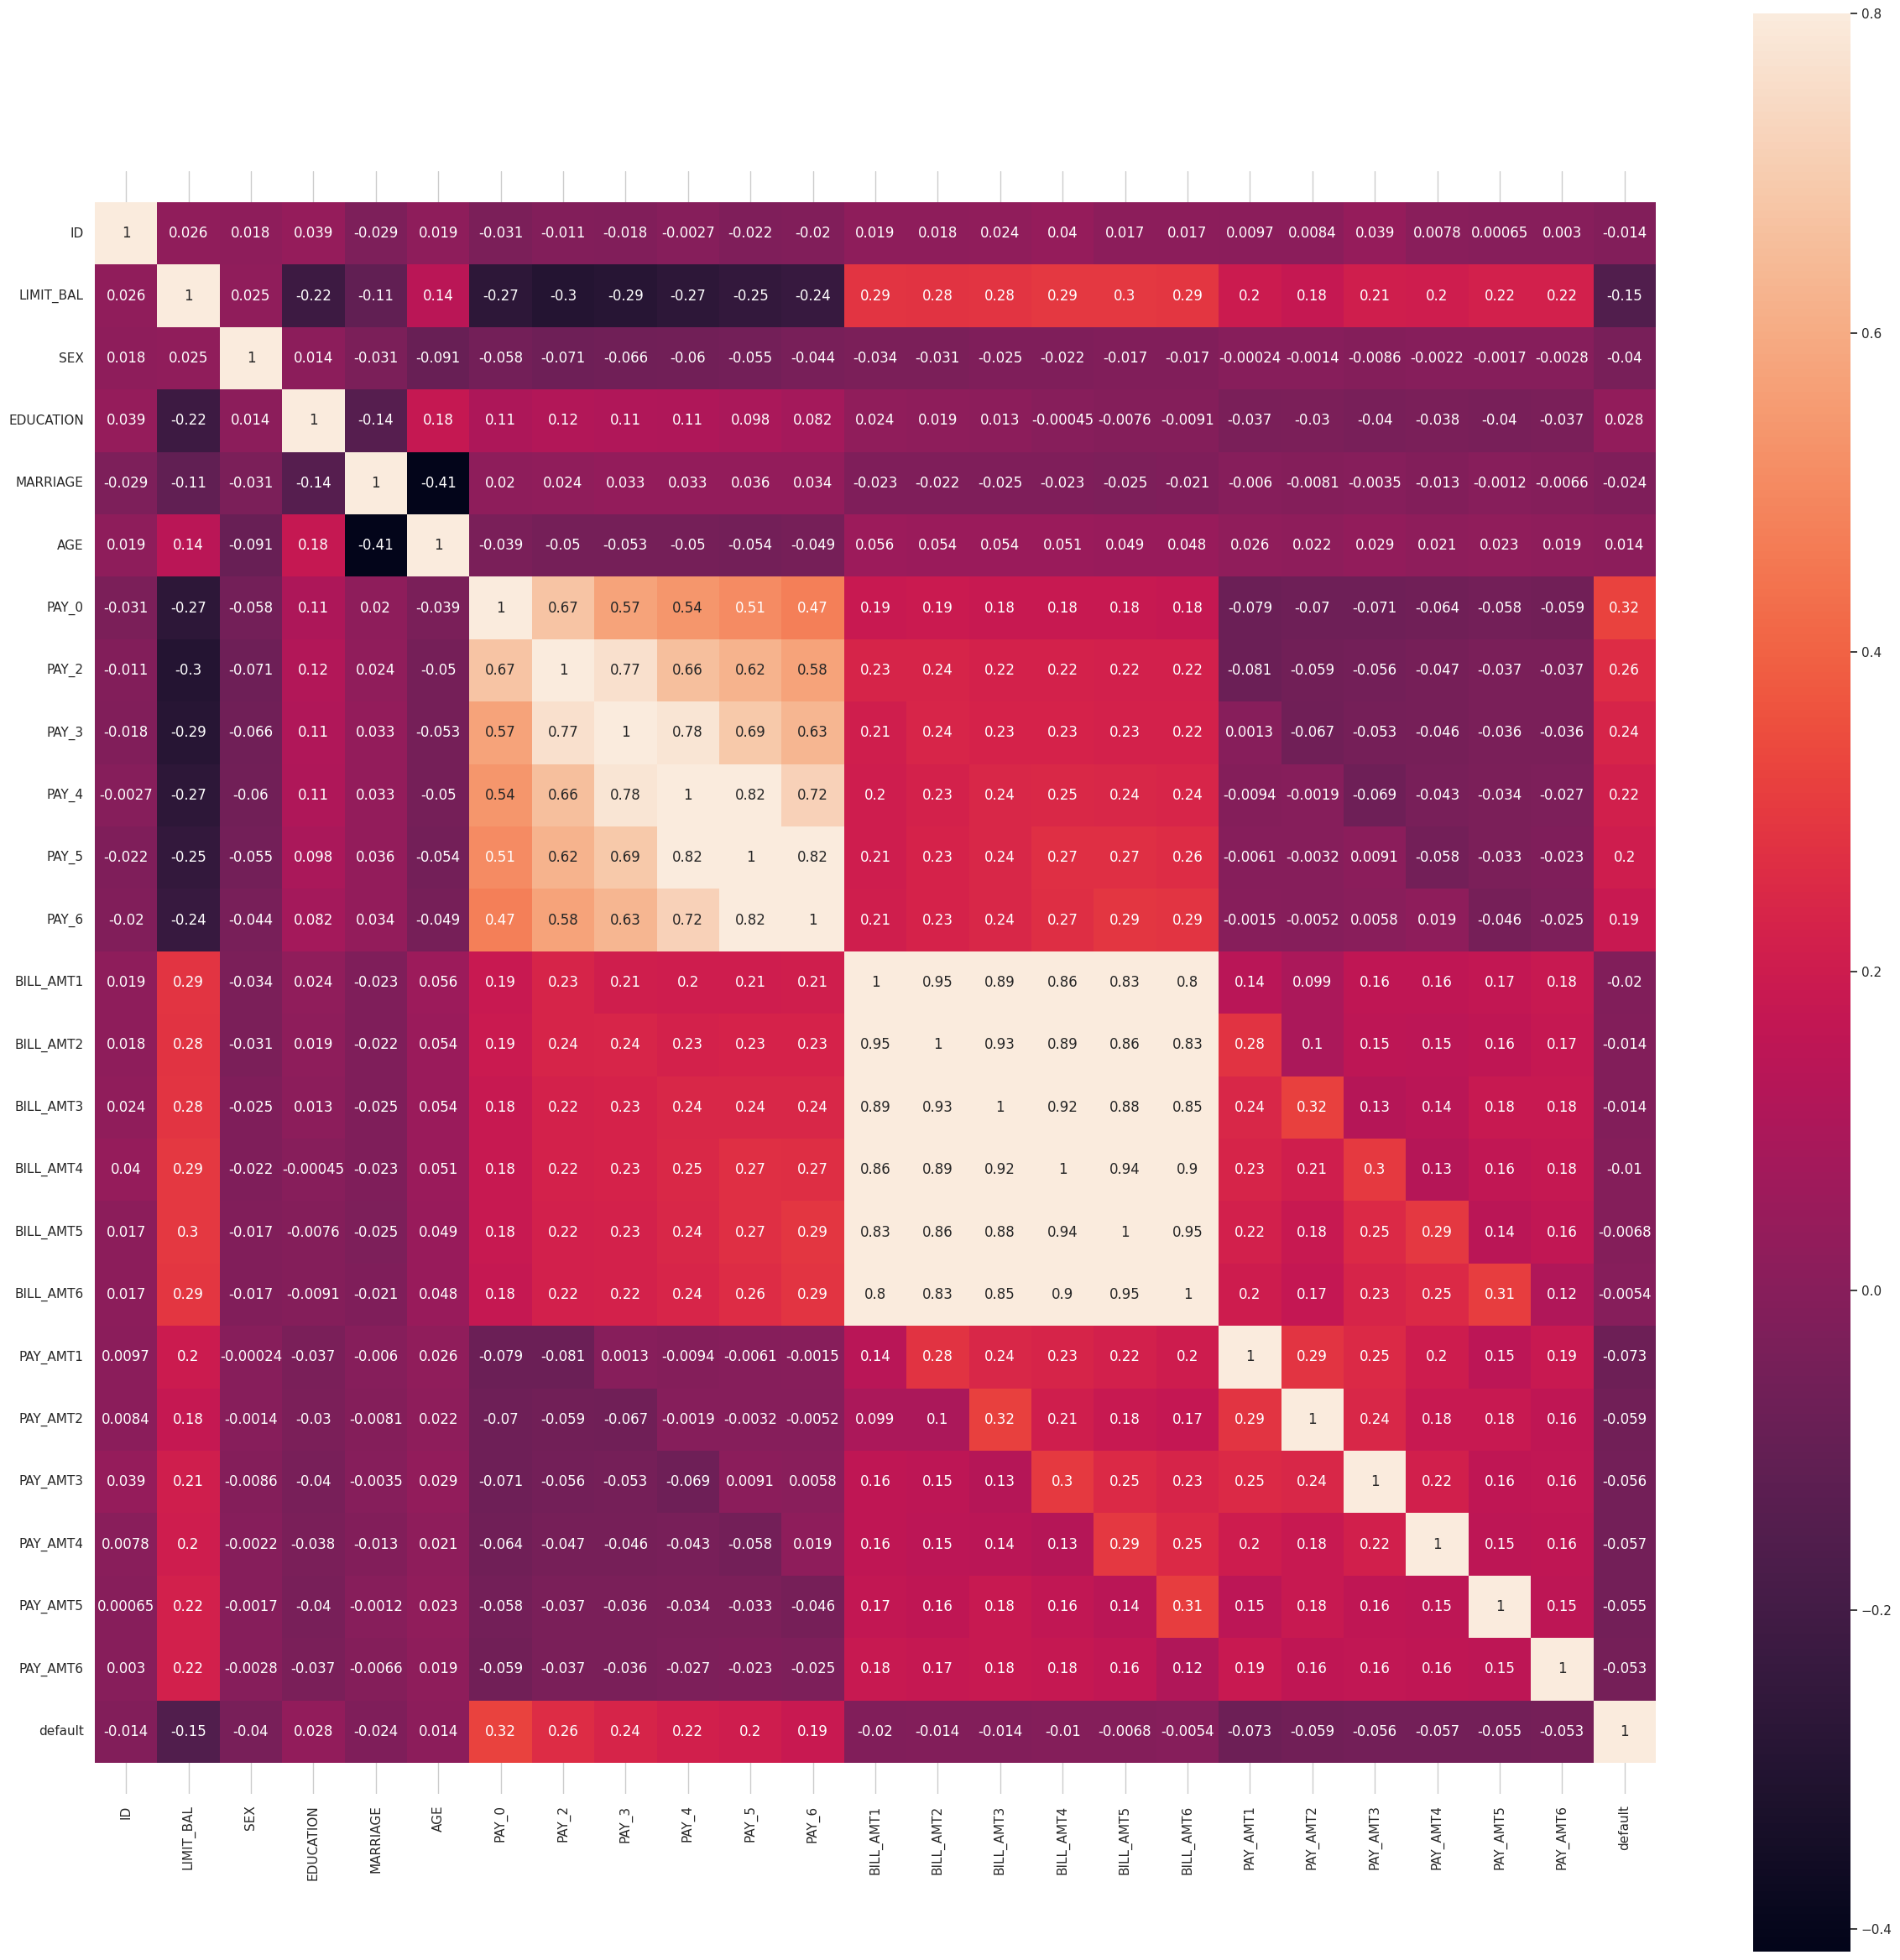

In [ ]:
# Correlation
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
corrmat = df[numerical_features].corr()

f, ax = plt.subplots(figsize=(30, 30))
ax=sb.heatmap(corrmat, vmax=.8, square=True, annot = True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom+0.5, top-0.5)

**NOTA:** El mapa de calor muestra la correlación entre los features que presenta el dataset. Se observa que la mayoría de las correlaciones son débiles o moderadas, tanto positivas como negativas. Por ejemplo:



**1. Alta multicolinealidad en BILL_AMT (saldos de factura):**
Las variables BILL_AMT1 a BILL_AMT6 presentan correlaciones extremadamente altas
entre sí (entre 0.80 y 0.95), lo que indica que el saldo de un mes es muy
predecible a partir del mes anterior. Esto genera multicolinealidad severa y
justifica el uso de Ridge Regression (L2).

**2. Correlación moderada entre PAY_0 a PAY_6 (historial de pagos):**
Las variables de estado de pago presentan correlaciones moderadas entre sí
(entre 0.47 y 0.82), siendo PAY_0 la que mayor correlación tiene con el
target default (0.32), lo que la convierte en la variable más predictiva
del dataset.

**3. Variables sensibles con baja correlación con el target:**
- SEX: correlación con default = -0.04 (prácticamente nula)
- MARRIAGE: correlación con default = -0.024 (prácticamente nula)
- AGE: correlación con default = 0.014 (prácticamente nula)
Esto sugiere que estas variables tienen muy poco poder predictivo sobre
el default.

**4. LIMIT_BAL con correlación negativa con default (-0.15):**
A mayor límite de crédito, menor probabilidad de default. Esto quiere decir que clientes con mayor límite suelen tener mejor historial crediticio.

**5. ID sin correlación relevante:**
La variable ID presenta correlaciones cercanas a 0 con todas las variables,
confirmando que es un identificador sin valor predictivo y debe ser
eliminado en el preprocesamiento.


## **2.4. Gráficos**

In [ ]:
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)


### **ID**

<Axes: xlabel='ID', ylabel='Density'>

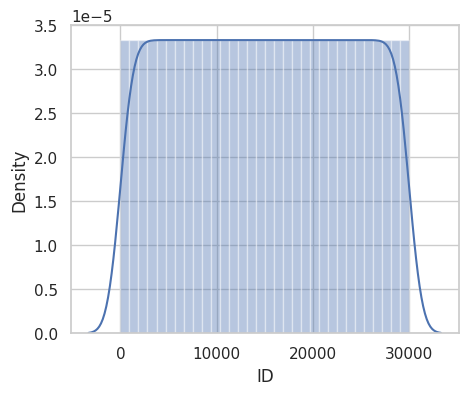

In [ ]:
sb.distplot(df['ID'])

**NOTA:** La distribución de la variable ID presenta una distribución uniforme perfecta, con densidad constante de 1 a 30000, lo que confirma que es un identificador secuencial asignado a cada cliente y que no contiene información predictiva sobre el comportamiento de pago. Por tanto, esta variable debe ser eliminada en la etapa de preprocesamiento.

### **LIMIT_BAL**

<Axes: xlabel='LIMIT_BAL', ylabel='Density'>

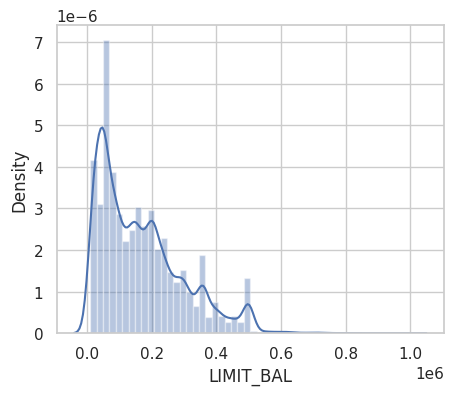

In [ ]:
sb.distplot(df['LIMIT_BAL'])

**NOTA:** La variable LIMIT_BAL presenta una distribución sesgada a la derecha, con la mayoría de los clientes concentrados en límites bajos, es decir, entre 10.000 y 100.000 NTS y una cola larga hacia valores altos que llegan hasta 1.000.000 NTS. Asimismo, se observan pequeños picos secundarios alrededor de 200.000 y 500.000 NTS.

Por tanto, según su distribución esta variable requiere StandardScaler en el preprocesamineto, debido a su alta variabilidad y sesgo, ello para evitar que su escala domine el modelo.

### **SEX**

In [ ]:
df['SEX'].value_counts()

,count
SEX,
2,18112
1,11888


<Axes: xlabel='SEX', ylabel='Density'>

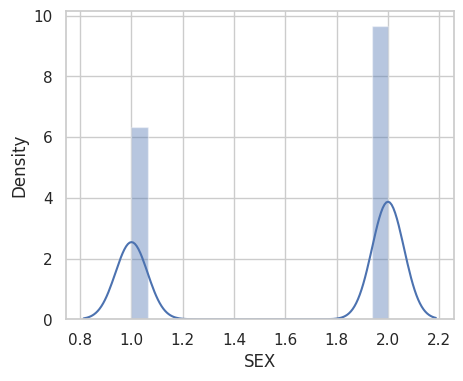

In [ ]:
sb.distplot(df['SEX'])

**NOTA:** La variable SEX presenta una distribución bimodal, ya que solo toma dos valores: 1 (hombre) y 2 (mujer). Este comportamiento es característico de las variables categóricas binarias, aunque en este caso está codificada como numérica. La gráfica confirma que existe mayor cantidad de mujeres en el dataset (18.112 a 11.888), lo que indica un desbalance demográfico en el dataset.

**Nota ética**: Dado que la correlación de SEX con el target default es prácticamente nula, -0.04, su inclusión en el modelo no mejora significativamente el poder predictivo pero sí podría introducirriesgo de sesgo de género. Esta variable será evaluada en el análisis con/sin variables sensibles antes de decidir su inclusión final.

### **EDUCATION**

In [ ]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


<Axes: xlabel='EDUCATION', ylabel='Density'>

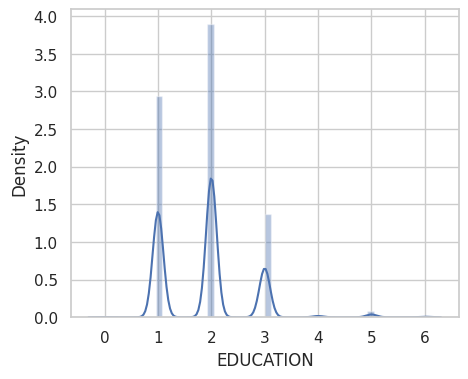

In [ ]:
sb.distplot(df['EDUCATION'])

**NOTA:** La variable EDUCATION que esta codificada como 1 (posgrado), 2 (universidad), 3 (secundaria)
y 4 (otros), 5 (desconocido) y 6 (desconocido). En su distribución demuestra que la categoría 2 (universidad) es la más frecuente con 14.030, seguida de la categoría 1 con 10.585 y la categoría 3 con 4917. Asimismo, se detectan valor de 0, 5 y 6 que no  corresponden a categorías válidas según el diccionario de datos original, representando registros con información desconocida o no documentada.

En el preprocesamiento, se deben agrupar los valores de 0, 5 y 6 dentro de la categoría 4, ello con el fin de consolidar todas las categorías no definidas en una sola para poder reducir el ruido en esta variable

### **MARRIAGE**

In [ ]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


<Axes: xlabel='MARRIAGE', ylabel='Density'>

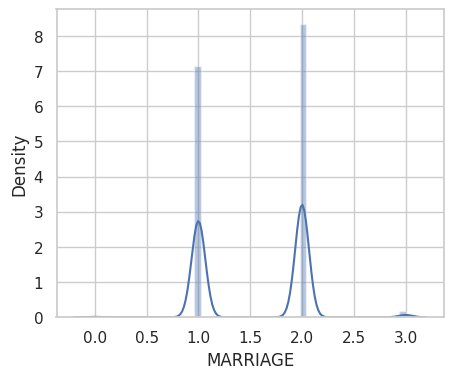

In [ ]:
sb.distplot(df['MARRIAGE'])

**NOTA:** La variable MARRIAGE está codificada como como 1 (casado), 2 (soltero) y 3 (otros). Asimismo, la distribución muestra que las categorías 1 y 2 concentran prácticamente todos los registros, siendo la categoría 2 ligeramente mas frecuente que la categoría 1. Lo que quiere decir que existen mas personas solteras que casadas registradas.

**Nota ética**: Al igual que SEX, la correlación de MARRIAGE con el target default es prácticamente nula (-0.024). Su inclusión será evaluada en el análisis de variables sensibles antes de decidir si se incorpora al modelo final.

### **AGE**

In [ ]:
df['AGE'].value_counts()

,count
AGE,
29,1605
27,1477
28,1409
30,1395
26,1256
31,1217
25,1186
34,1162
32,1158


<Axes: xlabel='AGE', ylabel='Density'>

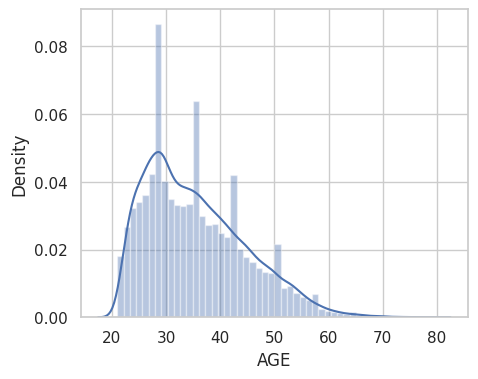

In [ ]:
sb.distplot(df['AGE'])

**NOTA:** La variable AGE muestra una distribución normal sesgada a la derecha con concentración principal entre los 25 y 35 años, siendo 29 años el valor mas frecuente (1605 clientes tienen esa edad). La cola se extiende hasta los 79 años con muy pocos registros de personas mayores de 60. Esto refleja que la cartera de clientes del banco es predominantemente joven.

**Nota ética**: AGE tiene correlación prácticamente nula con default (0.014). La discriminación por edad está prohibida en muchos marcosregulatorios, por lo que su inclusión será evaluada cuidadosamenteen el análisis de variables sensibles.

### **PAY_0**

<Axes: xlabel='PAY_0', ylabel='Density'>

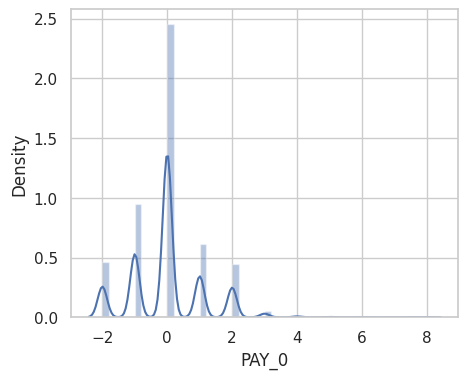

In [ ]:
sb.distplot(df['PAY_0'])

**NOTA:** La variable PAY_0 representa el estado de pago del mes más reciente (septiembre 2005), codificado como -2 (sin consumo), -1 (pagó a tiempo), 0 (uso de crédito rotativo) y valores positivos 1-8 que indican meses de retraso en el pago.

La distribución muestra una fuerte concentración en 0 y -1, lo que indica que la mayoría de los clientes pagaron a tiempo o usaron crédito rotativo.
La cola hacia valores positivos (retrasos) es corta pero relevante, ya que como se observó en la matriz de correlación, PAY_0 es la variable con mayor correlación con el target default (0.32)

Asimismo, PAY_0 será tratada como variable categórica
ordinal en el pipeline, dado que sus valores representan niveles de retraso con un orden natural.

### **PAY_2**

<Axes: xlabel='PAY_2', ylabel='Density'>

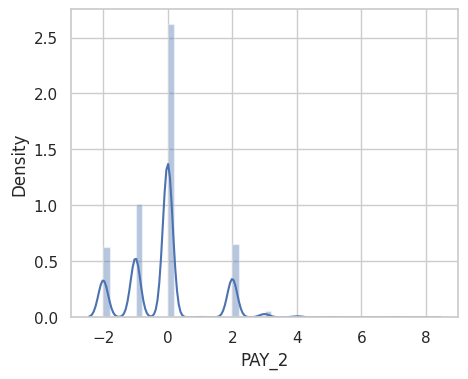

In [ ]:
sb.distplot(df['PAY_2'])

### **PAY_3**

<Axes: xlabel='PAY_3', ylabel='Density'>

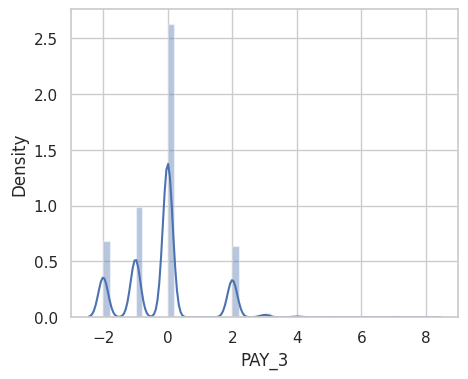

In [ ]:
sb.distplot(df['PAY_3'])

### **PAY_4**

<Axes: xlabel='PAY_4', ylabel='Density'>

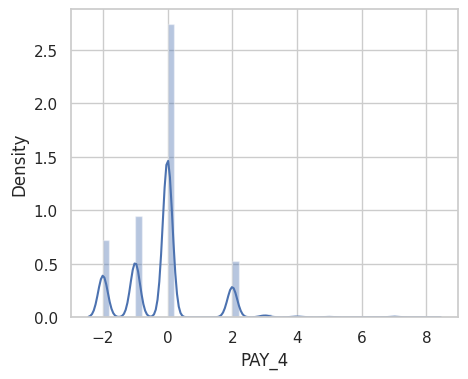

In [ ]:
sb.distplot(df['PAY_4'])

### **PAY_5**

<Axes: xlabel='PAY_5', ylabel='Density'>

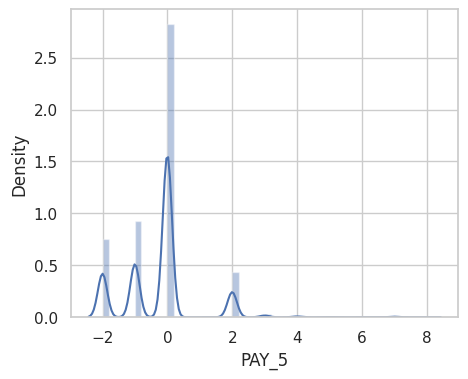

In [ ]:
sb.distplot(df['PAY_5'])

### **PAY_6**

<Axes: xlabel='PAY_6', ylabel='Density'>

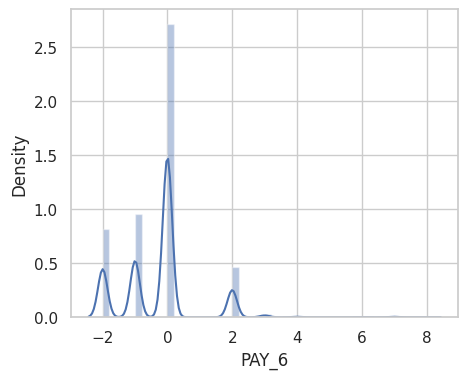

In [ ]:
sb.distplot(df['PAY_6'])

**NOTA:** Las variables PAY_2 a PAY_6 representan el estado de pago de los meses anteriores (de abril a agosto de 2005) y presentan distribuciones muy similares a PAY_0, con fuerte concentración en los valores 0 y -1 (pago puntual o crédito rotativo) y colas cortas hacia valores positivos que indican retraso.

A medida que nos alejamos en el tiempo (de PAY_2 a PAY_6), la concentración en valores negativos tiende a aumentar ligeramente, lo que es consistente con el hecho de que clientes que eventualmente entraron en default comenzaron a mostrar señales de retraso en meses más recientes.

Asimismo, todas las variables PAY_0 a PAY_6 serán
tratadas como variables categóricas ordinales en el pipeline.

### **BILL_MT1 a BILL_MT6**

Para poder analizar la distribucion de cada una de las variables de manera mas detallada se realizo historigramas sobre las varibles referidas a BILL_AMT. Ademas, debido a que un objetivo es poder realizar un modelo de clasificacion con el feature default.payment.next.month, para las distribuciones se tendra esto es cuenta.
Se hara la comparacion de las dictruciones de los BILL_AMT donde se marque de un color diferente sobre el resultado de los clientes con incumpliento y los que estan al dia.

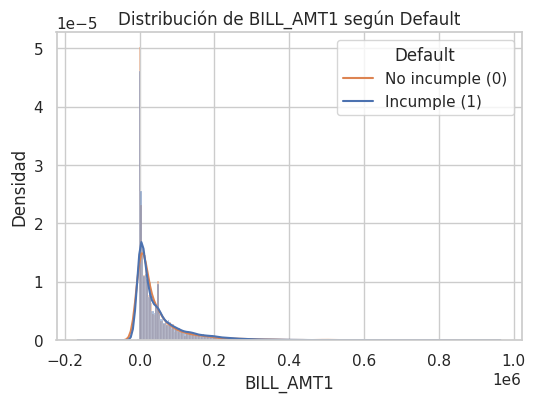

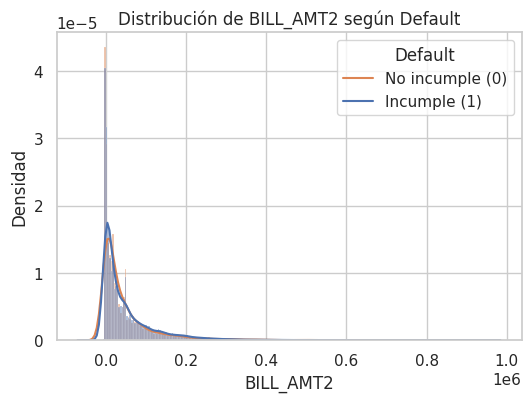

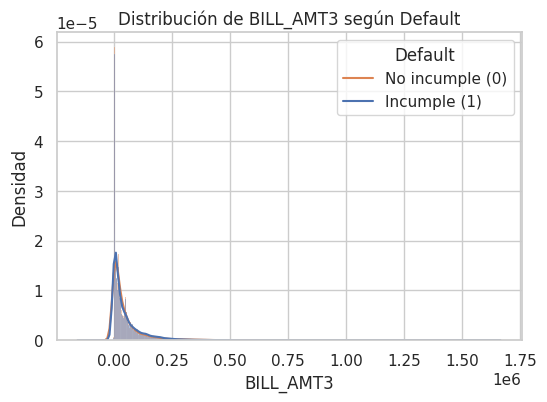

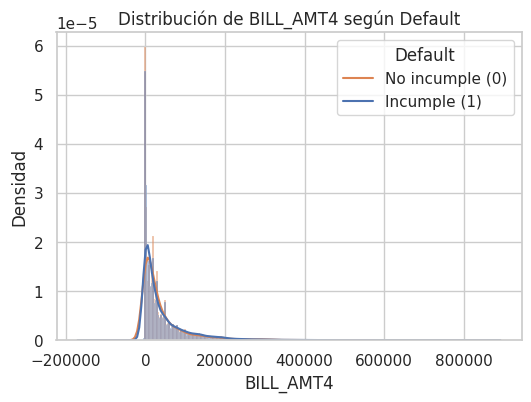

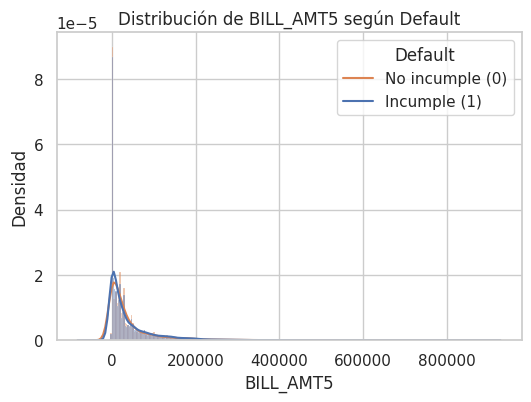

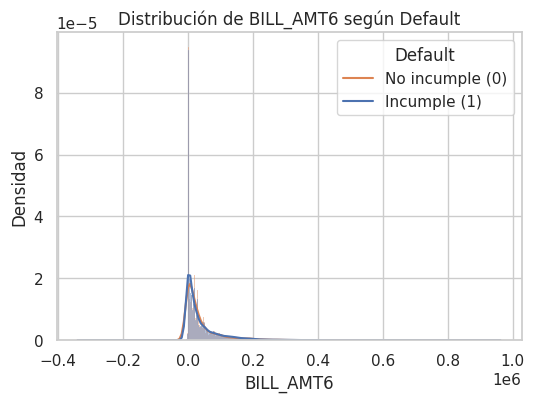

In [ ]:
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]

for col in bill_cols:
    plt.figure(figsize=(6,4))

    sb.histplot(data=df, x=col,hue="default", kde=True, stat="density", common_norm=False)

    plt.title(f"Distribución de {col} según Default")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend(title="Default", labels=["No incumple (0)", "Incumple (1)"])

    plt.show()

**NOTA:** Se realizó una gráfica para poder comparar que todas las variables de esta categoría demuestren una distribución similar sesgada hacia los valores mas altos.

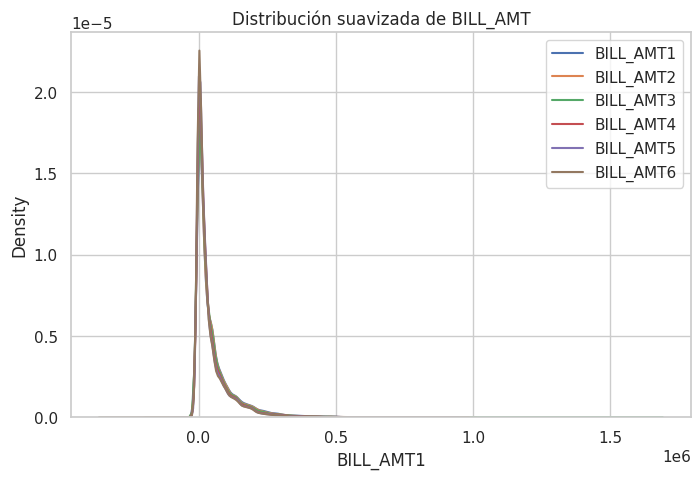

In [ ]:
plt.figure(figsize=(8,5))

for col in bill_cols:
    sb.kdeplot(df[col], label=col)

plt.title("Distribución suavizada de BILL_AMT")
plt.legend()
plt.show()

**Observaciones**



*   Las variables tienen una distribución similar
*   Todas las variables de BILL_AMT se encuentran sesgadas a la derecha


*   Debido a que la distribución entre aquellos que tienen incumplimiento y los que no, se superponen se de a entender que esta variable no llega a afectar mucho a predecir si un cliente es incumplido o no

### **PAY_AMT1 a PAY_AMT5**

Se realizó el  mismo procedimiento que con BILL_AMT para PAY_AMT, donde tambien se comparo dlas distribuciones de los PAY_AMT donde se marque de un color diferente sobre el resultado de los clientes con incumpliento y los que estan al dia.

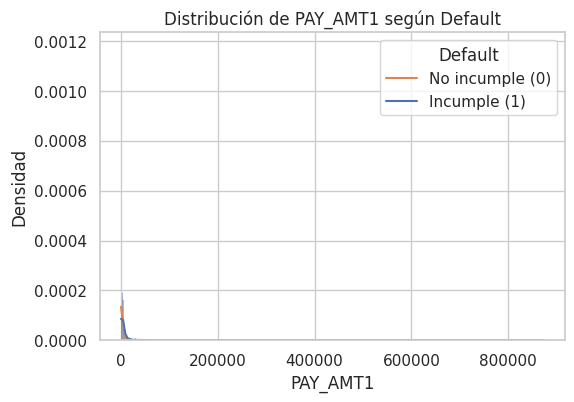

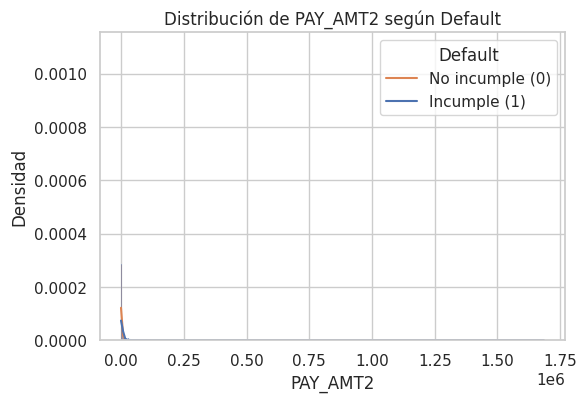

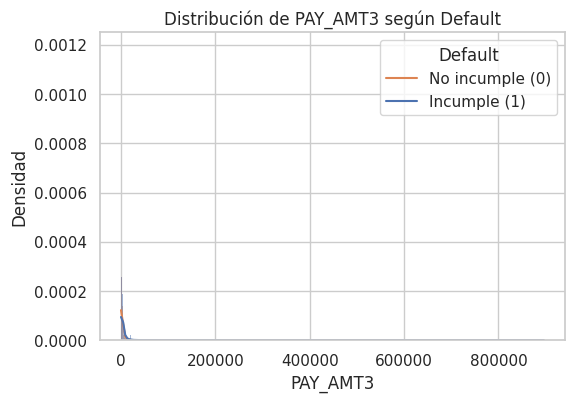

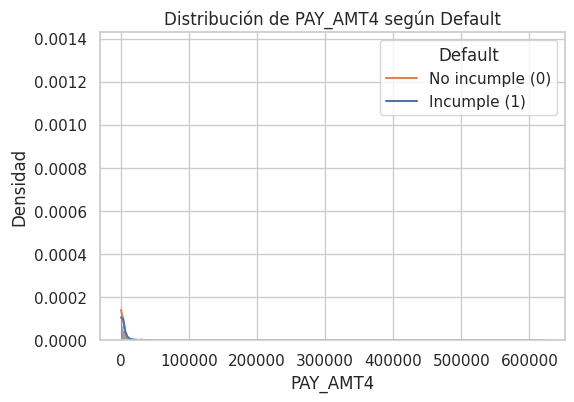

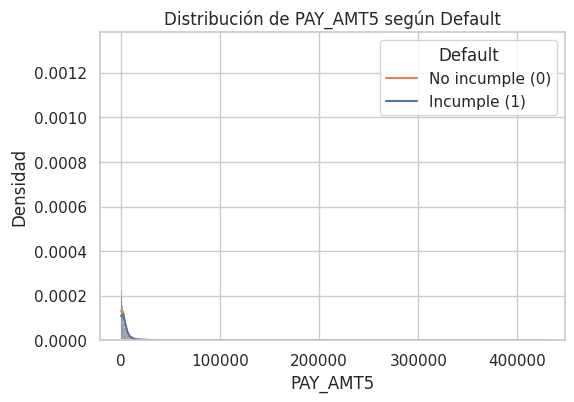

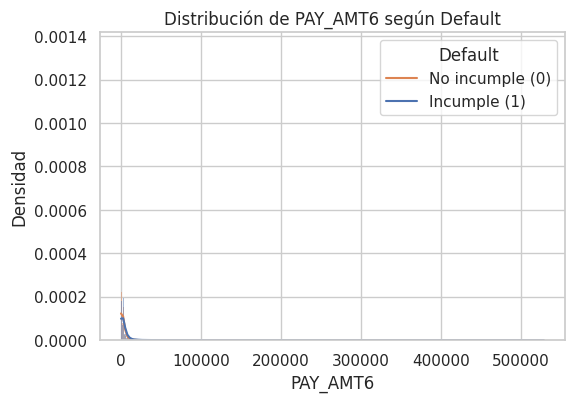

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

pay_cols = [f"PAY_AMT{i}" for i in range(1,7)]

for col in pay_cols:
    plt.figure(figsize=(6,4))

    sb.histplot(data=df, x=col,hue="default", kde=True, stat="density", common_norm=False)

    plt.title(f"Distribución de {col} según Default")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend(title="Default", labels=["No incumple (0)", "Incumple (1)"])

    plt.show()

**Observaciones**
*   Las varibles tienen una distribución similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha de manera mas radical
*   Debido a que la distribución entre aquellos que tienen incumplimiento y los que no, se superponen se de a entender que esta variable no llega a afectar mucho a predecir si un cliente es incumplido o no

### **2.4.1 BOXPLOT**

**BILL_AMT**

Para poder confirmar el sesgo de estas variables se realizo la grafica de boxplot

**Observaciones**
*   Las varibles tienen una distribucion similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha

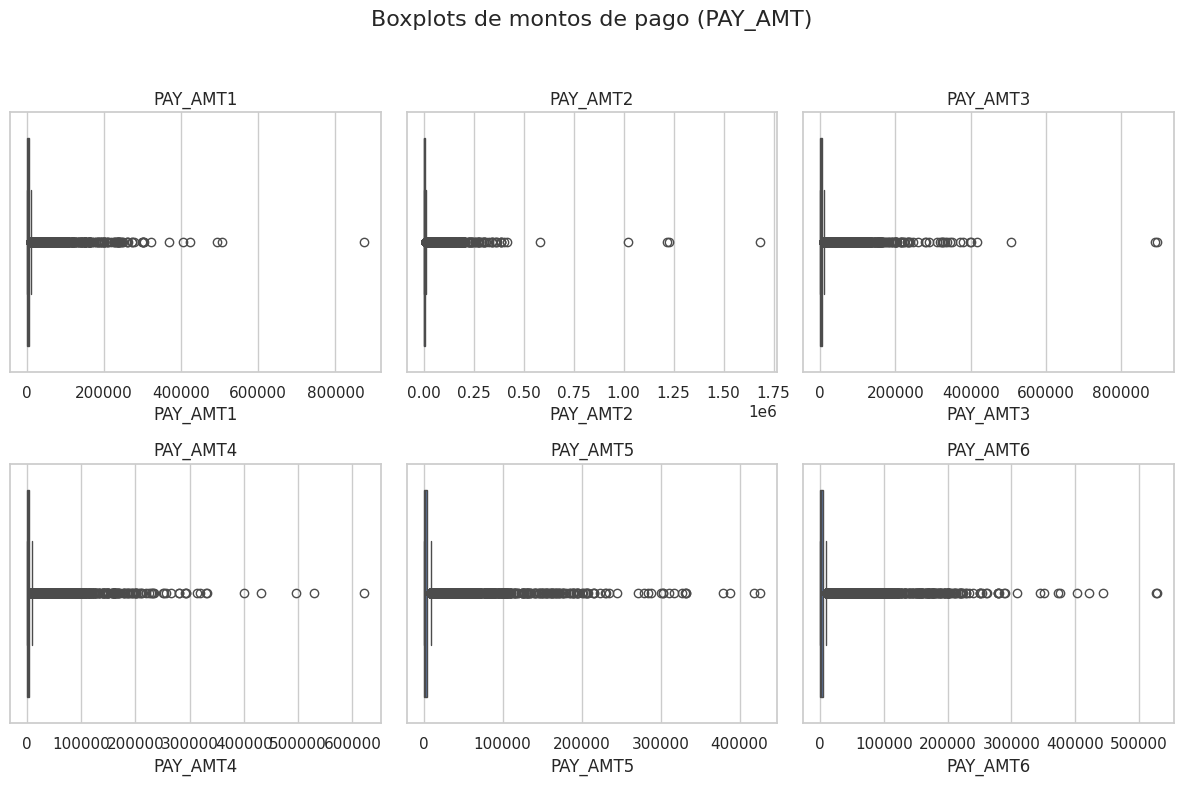

In [ ]:
# Crear figura con subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
fig.suptitle('Boxplots de montos de pago (PAY_AMT)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(pay_cols):
    sb.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# eliminar ejes vacíos si hubiera
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**PAY_AMT**

Se realizo el  mismo procedimiento que con BILL_AMT para PAY_AMT
**Observaciones**
*   Las varibles tienen una distribucion similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha de manera mas radical

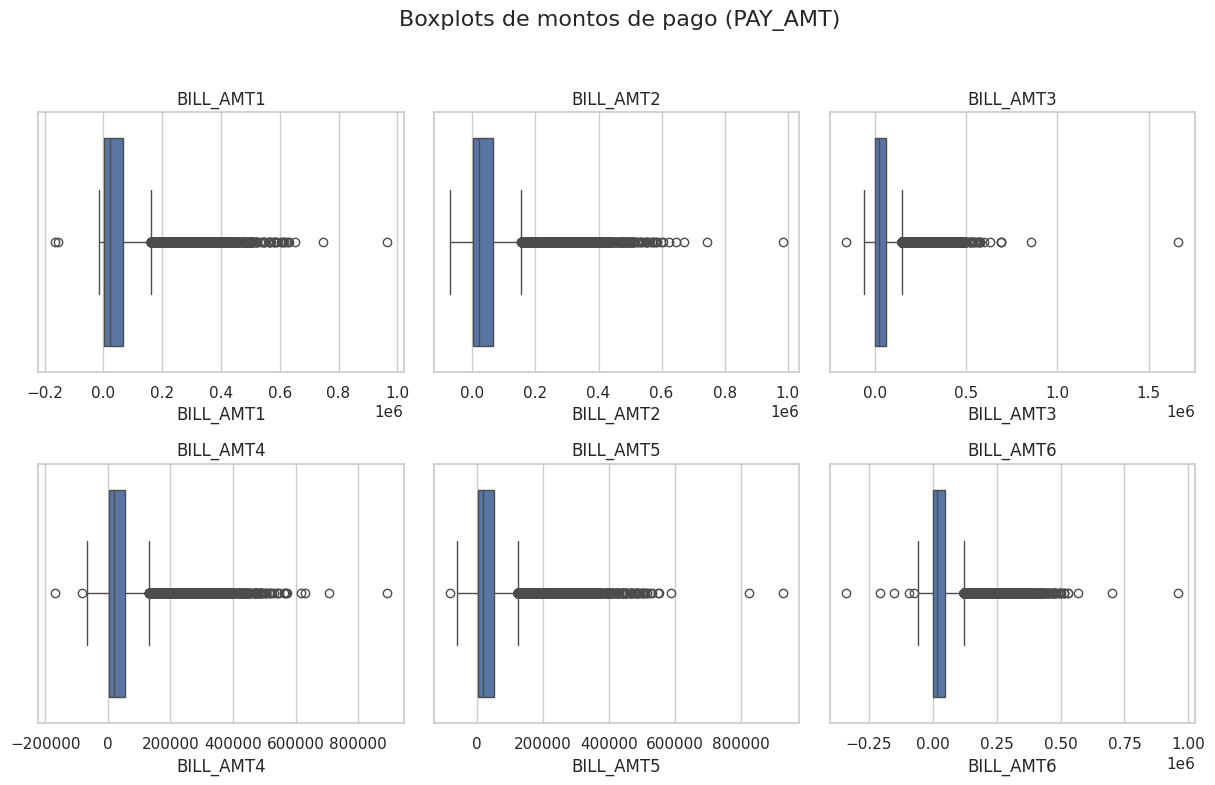

In [ ]:
# Crear figura con subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
fig.suptitle('Boxplots de montos de pago (PAY_AMT)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(bill_cols):
    sb.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# eliminar ejes vacíos si hubiera
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**NOTA:** No se realizó el bloxplot ni hisotgrama para la variable "default.payment.next.month", debido a que esta es una varible dicotomica, y no nos provee de información relevante realizar este tipo de gráficos.

### **2.4.2. Tasa de Default por Variables Sensibles (SEX, EDUCATION, MARRIAGE)**

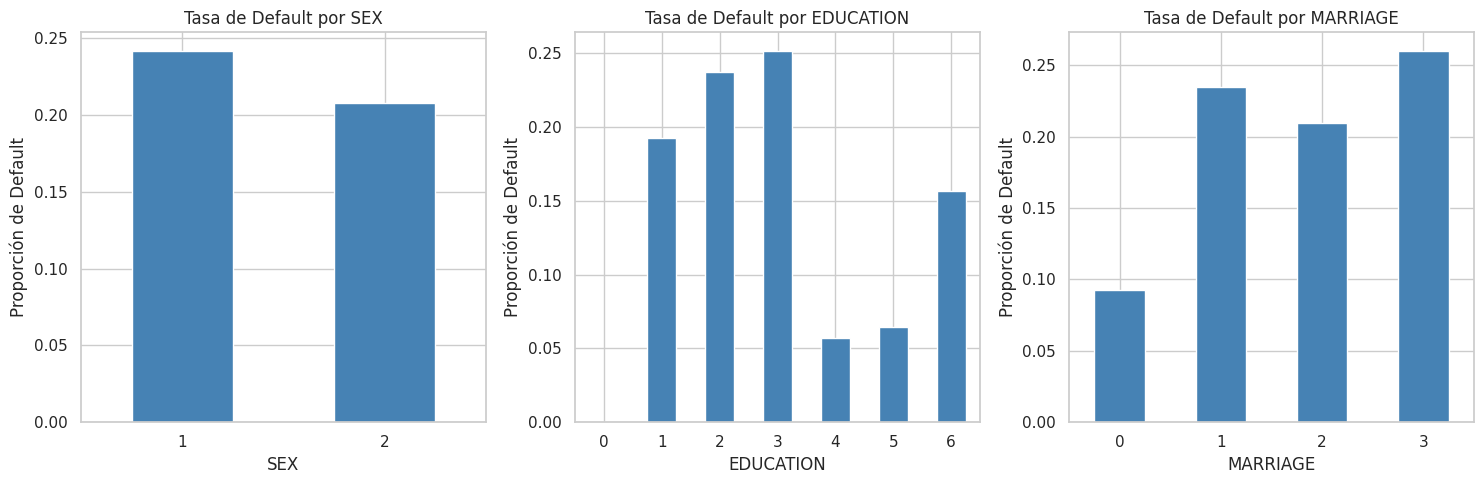

In [ ]:
# Tasa de default por SEX, EDUCATION y MARRIAGE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Tasa de Default por {col}')
    ax.set_ylabel('Proporción de Default')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**NOTA:**


**SEX**: Los hombres presentan una tasa de default de 24%, ligeramente superior a las mujeres con 21%. Si bien existe una diferencia de 3 puntos porcentuales. Recordando que
la correlación de SEX con default era de apenas -0.04, esta diferencia visual podría explicarse por otros factores como el límite de crédito o el historial de pagos, y no necesariamente por el género en sí.

**EDUCATION**: Se observa un patrón interesante donde los clientes con educación secundaria (3) presentan la mayor tasa de default (25%), seguidos de universidad (2) con 23% y posgrado (1) con 19%. Las categorías 4 y 5 (otros/desconocido)
muestran tasas anormalmente bajas (6%), lo que refuerza la decisión de agruparestas categorías no documentadas en preprocesamiento, ya que podrían estar introduciendo ruido en el modelo.

**MARRIAGE**: Los clientes con estado civil 3 (otros) presentan la tasa de default más alta (26%), seguidos de casados (1) con 23% y solteros (2) con 21%. Destaca la categoría 0 (no documentada) con una tasa muy baja (~9%), lo que nuevamente sugiere que estas categorías inválidas deben ser tratadas en preprocesamiento.


### **LIMIT_BAL según Default**

<Figure size 800x500 with 0 Axes>

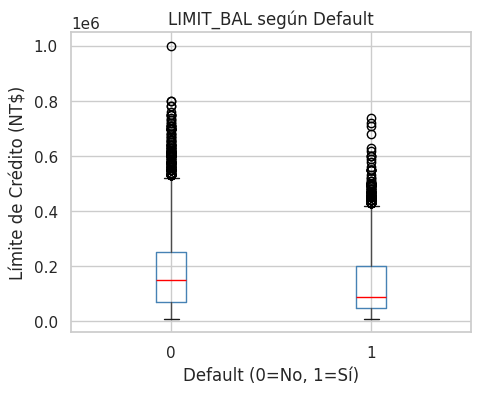

In [ ]:
# Boxplot de LIMIT_BAL según default
plt.figure(figsize=(8, 5))
df.boxplot(column='LIMIT_BAL', by='default',
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
plt.title('LIMIT_BAL según Default')
plt.suptitle('')
plt.xlabel('Default (0=No, 1=Sí)')
plt.ylabel('Límite de Crédito (NT$)')
plt.show()

**NOTA:** El boxplot muestra una diferencia clara en el límite de crédito entre clientes que hicieron default (1) y los que no (0). Los clientes sin default presentan una mediana de límite de crédito  más alta  frente a los clientes en default. Esto es consistente con la correlación negativa de -0.15 observada en la matriz de correlación: a mayor límite de crédito, menor probabilidad de default.

Además, se observan múltiples outliers en ambos grupos, especialmente en el grupo sin default. Esto confirma la distribución sesgada a la derecha de LIMIT_BAL y refuerza la necesidad de aplicar StandardScaler en el pipeline para normalizar su escala.

### **Tasa de Default por Estado de Pago (PAY_0)**

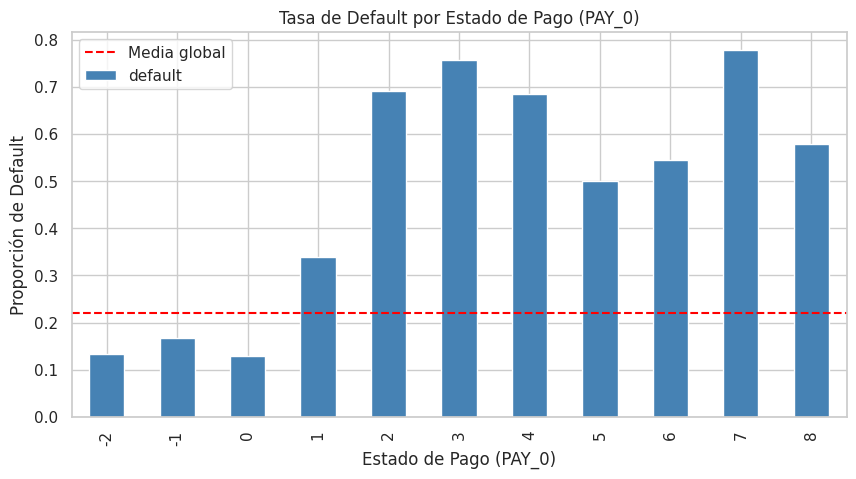

In [ ]:
# Tasa de default por estado de pago PAY_0
plt.figure(figsize=(10, 5))
df.groupby('PAY_0')['default'].mean().plot(kind='bar', color='steelblue')
plt.title('Tasa de Default por Estado de Pago (PAY_0)')
plt.xlabel('Estado de Pago (PAY_0)')
plt.ylabel('Proporción de Default')
plt.axhline(df['default'].mean(), color='red', linestyle='--', label='Media global')
plt.legend()
plt.show()

**NOTA:** Se observa que existe una relación clara entre el retraso en los pagos (PAY_0) y la probabilidad de default. Los clientes que pagan a tiempo o no presentan consumo (PAY_0 = -2 o -1) tienen una tasa de default baja, alrededor del 13-16%, por debajo del promedio del dataset. Cuando aparece un mes de retraso (PAY_0 = 1), la probabilidad de default aumenta a aproximadamente 34%. A partir de dos meses de retraso, la probabilidad supera el 69%, lo que indica un riesgo muy alto de incumplimiento. Esto muestra que PAY_0 es una de las variables más importantes para predecir el default, ya que incluso un pequeño retraso puede ser una señal temprana de riesgo para el banco.

### **AGE vs LIMIT_BAL por Default**

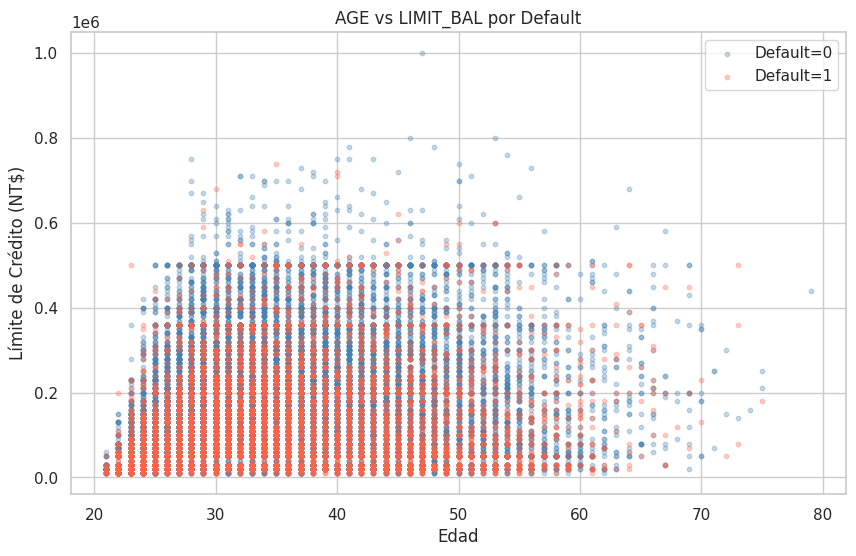

In [ ]:
# Scatter plot AGE vs LIMIT_BAL coloreado por default
plt.figure(figsize=(10, 6))
colors = {0: 'steelblue', 1: 'tomato'}
for val, group in df.groupby('default'):
    plt.scatter(group['AGE'], group['LIMIT_BAL'],
                alpha=0.3, s=10,
                color=colors[val],
                label=f'Default={val}')
plt.title('AGE vs LIMIT_BAL por Default')
plt.xlabel('Edad')
plt.ylabel('Límite de Crédito (NT$)')
plt.legend()
plt.show()

**NOTA:** Los puntos rojos (default) y azules (no default) aparecen mezclados, lo que indica que la edad y el límite de crédito por sí solos no permiten distinguir claramente quién hará default. Sin embargo, se observa que los límites de crédito muy altos (más de 600,000 NT$) suelen corresponder a clientes que no presentan incumplimiento, lo que sugiere que un mayor límite de crédito podría estar asociado a clientes con menor riesgo.

### **Tasa de Default por Género y Estado de Pago (PAY_0)**

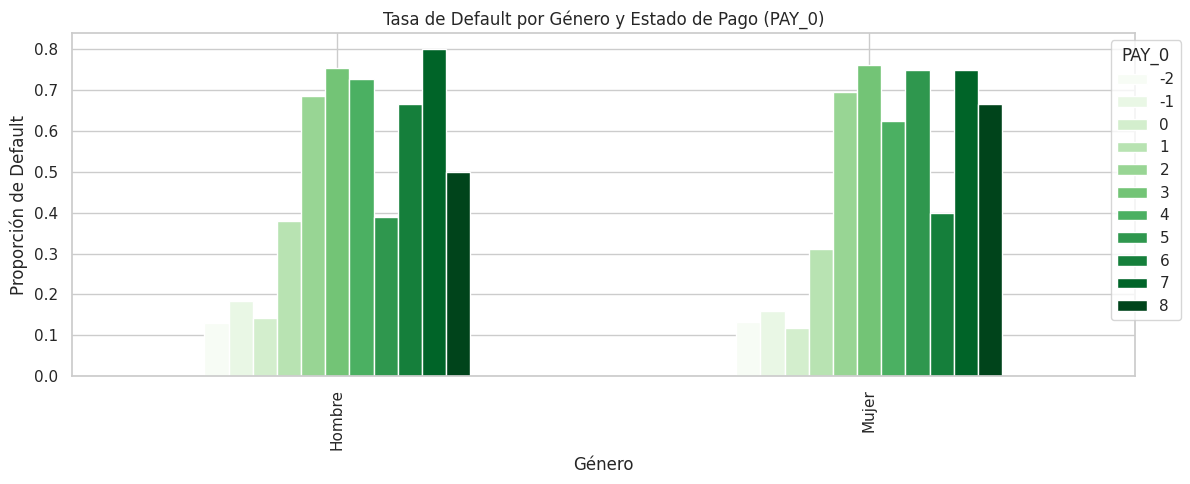

In [ ]:
# Retrasos por Género
pivot = df.groupby(['SEX', 'PAY_0'])['default'].mean().unstack()
pivot.index = ['Hombre', 'Mujer']

pivot.plot(kind='bar', figsize=(12, 5), colormap='Greens')
plt.title('Tasa de Default por Género y Estado de Pago (PAY_0)')
plt.xlabel('Género')
plt.ylabel('Proporción de Default')
plt.legend(title='PAY_0', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**NOTA:** Se observa que la proporción de default aumenta a medida que aumenta el retraso en los pagos (PAY_0), tanto en hombres como en mujeres. Es decir, el número de meses de retraso es un factor mucho más importante para explicar el default que el género del cliente. Aunque existen pequeñas diferencias entre hombres y mujeres, el patrón general es el mismo: cuando el retraso supera uno o dos meses, la probabilidad de incumplimiento aumenta considerablemente.

### **Tasa de Default por Educación y Estado de Pago (PAY_0)**

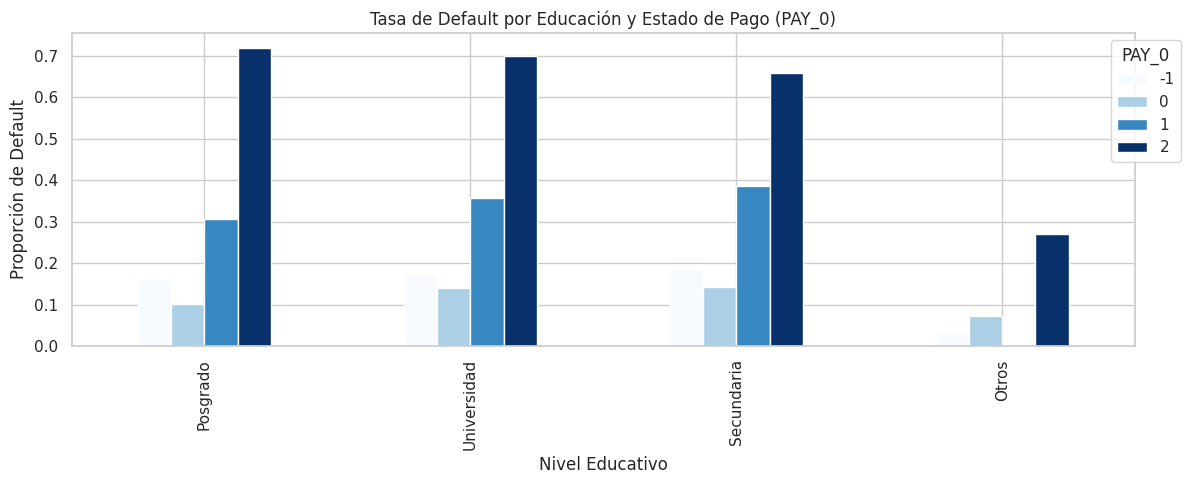

In [ ]:
# Copia par la visualizacion por el preprocesamiento
df_viz = df.copy()
df_viz['EDUCATION'] = df_viz['EDUCATION'].replace([0, 5, 6], 4)

pivot2 = df_viz.groupby(['EDUCATION', 'PAY_0'])['default'].mean().unstack()
pivot2.index = ['Posgrado', 'Universidad', 'Secundaria', 'Otros']

pivot2[[-1, 0, 1, 2]].plot(kind='bar', figsize=(12, 5), colormap='Blues')
plt.title('Tasa de Default por Educación y Estado de Pago (PAY_0)')
plt.xlabel('Nivel Educativo')
plt.ylabel('Proporción de Default')
plt.legend(title='PAY_0', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

NOTA: Se observa que, independientemente del nivel educativo, la probabilidad de default aumenta cuando el cliente presenta retrasos en sus pagos (PAY_0). Es decir, el historial de pagos tiene un impacto mucho mayor en el riesgo de incumplimiento que el nivel educativo. Aunque pueden existir ligeras diferencias entre grupos educativos, el patrón general es similar: cuando aparece retraso en los pagos, la tasa de default aumenta notablemente.

## **2.5. HISTOGRAMA DE TODAS LAS VARIABLES**

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'SEX'}>,
        <Axes: title={'center': 'EDUCATION'}>,
        <Axes: title={'center': 'MARRIAGE'}>],
       [<Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'PAY_0'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>,
        <Axes: title={'center': 'PAY_4'}>],
       [<Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>,
        <Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>,
        <Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>],
       [<Axes: title={'center': 'PAY_AMT3'}>,
        <Axes: title={'center': 'PAY_AMT4'}>,
        <A

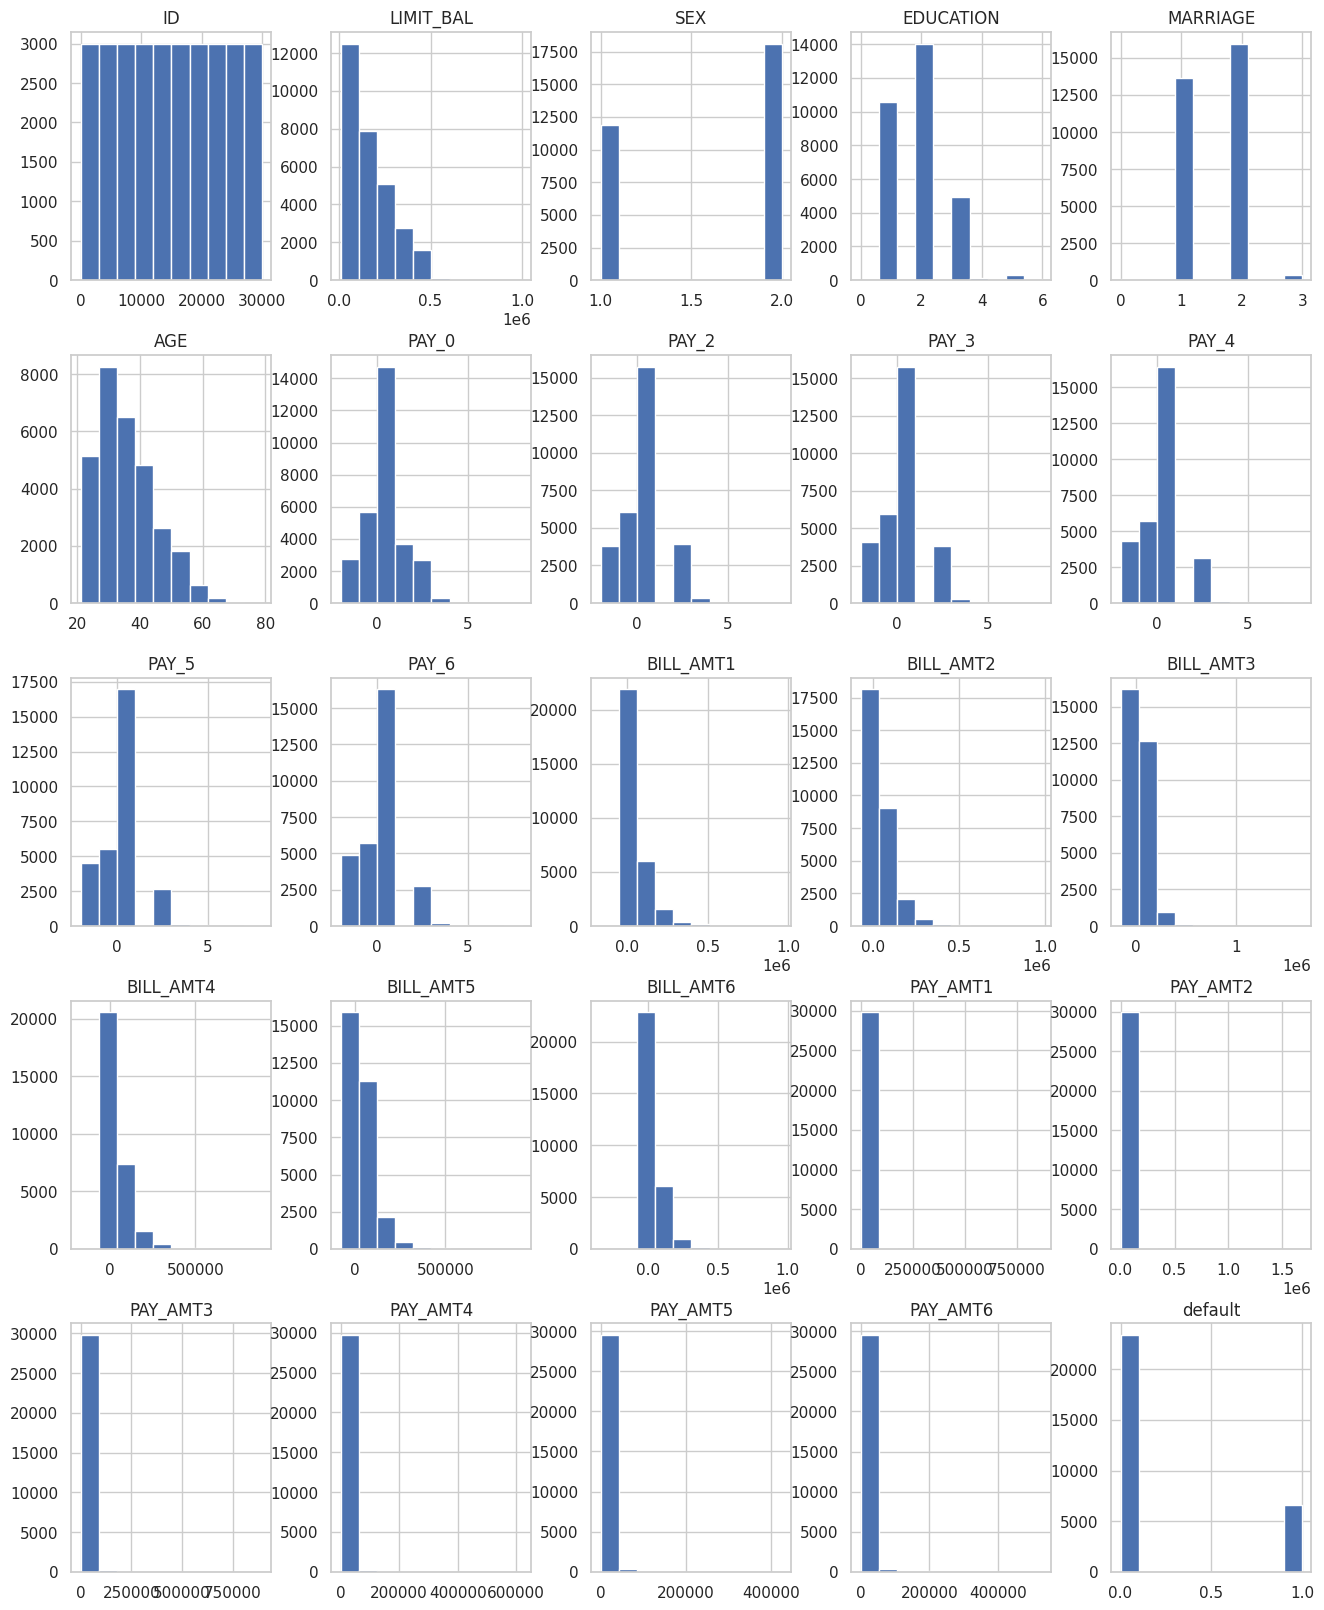

In [ ]:
df.hist(figsize=(16, 20))

**NOTA:** Como se peude evidenciar, se muestran los histogramas de las variables confirmando los gráficos y las distribuciones que siguen cada una de las variables anteriormente analizadas.

#**3. PREPROCESAMIENTO**

Despúes de realizar el EDA, se procedió a construir un proceso de preprocesamiento reproducible haciendo uso de Pipeline.

El objetivo de utilizar pipelines es evitar la fuga de información (data leakage) y asegurar que todas las tranformaciones se ajuten únicamente utilizando los datos de entrenamiento. De esta maner las estadísticas necesarias para el preprocesamiento se van a calcular solo en el conjunto de entenamiento para posteriormeten aplicarse en la validación y la prueba.


In [ ]:
# Importación de librerías
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
X = df.drop(columns=['default', 'PAY_AMT1'])

# Target clasificación
y_clf = df['default'].copy()

# Target regresión
y_reg = df['PAY_AMT1'].copy()

print(f"Features:            {X.shape}")
print(f"Target clasificación: {y_clf.shape} | clases: {y_clf.value_counts().to_dict()}")
print(f"Target regresión:     {y_reg.shape} | media: {y_reg.mean():.0f} NT$")

Features:            (30000, 23)
Target clasificación: (30000,) | clases: {0: 23364, 1: 6636}
Target regresión:     (30000,) | media: 5664 NT$


**NOTA:** Dado que este caso de estudio aborda problemas analíticos diferentes, se procede a definir por separado las variables predictoras o variables objetivo. Para clasificación, la variable objetivo ***defaullt***, la cual indica si en cliente incurre o no en incumplimiento de pago del siguiente mes. Por otro lado, para el problema de regresión, la variable objetivo  ***PAY_AMT1***, que representa el monto pagado por el cliente en el periodo mas reciente del dataset proporcionado.

Por tal motivo se procedio a eliminar dichas columnas ya que ambas se emplean como variables objetivo y no deben formar parte de las entradas del modelo. Esto nos permite trabajar con un mismo conjunto de características para construir dos modelos distintos.

Adicionalmente, se realizó una varificación de las dimensiones y distribución de las variables objetivo. En clasificación se reviso la cantidad de observaciones por clase, ello con el fin de poder identificar si existe desbalance entre clientes que hacen default y los que no. En este caso si existe un desbalance notorio ya que una clase cuenta con 23364 que equivale aproximadamente al 78% de los registros del dataset. En el caso de regresión, se verificó el tamaño del target y su valor promedio (5664), ello con el objetivo de tener una referencia inicial sobre la magnitud de los pagos.

### **División del Dataset y Estratificación**

In [ ]:
# Separar test (20%)
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for train_val_idx, test_idx in split1.split(X, y_clf):
    X_train_val      = X.iloc[train_val_idx]
    X_test           = X.iloc[test_idx]
    y_clf_train_val  = y_clf.iloc[train_val_idx]
    y_clf_test       = y_clf.iloc[test_idx]
    y_reg_train_val  = y_reg.iloc[train_val_idx]
    y_reg_test       = y_reg.iloc[test_idx]

In [ ]:
# Se divide el primer conjunto
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
for train_idx, val_idx in split2.split(X_train_val, y_clf_train_val):
    X_train      = X_train_val.iloc[train_idx]
    X_val        = X_train_val.iloc[val_idx]
    y_clf_train  = y_clf_train_val.iloc[train_idx]
    y_clf_val    = y_clf_train_val.iloc[val_idx]
    y_reg_train  = y_reg_train_val.iloc[train_idx]
    y_reg_val    = y_reg_train_val.iloc[val_idx]

**NOTA:** Se procede a dividir el dataset en dos partes, un conjunto de entrenamiento (60%), validación (20%) y otro conjunto de prueba (20%). Esta división se la realizó con *StratifiedShuffleSplit*, que nos permite mantener la misma proporción de clases de la variable default en ambos conjuntos.

El objetivo de esta división es reservar el conjunto de test solo para la evaluación final del modelo, mientras que el conjunto de train y validation se utilizarán para entrenar los modelos y ajustar sus parámetros.

In [ ]:
# Verificar tamaños y proporciones
print(f"\nTamaños del split:")
print(f"  Train:      {X_train.shape[0]:>6,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:>6,} ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:>6,} ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nProporción de default (clase 1) — verificar estratificación:")
print(f"  Train:      {y_clf_train.mean():.3f}")
print(f"  Validation: {y_clf_val.mean():.3f}")
print(f"  Test:       {y_clf_test.mean():.3f}")


Tamaños del split:
  Train:      18,000 (60%)
  Validation:  6,000 (20%)
  Test:        6,000 (20%)

Proporción de default (clase 1) — verificar estratificación:
  Train:      0.221
  Validation: 0.221
  Test:       0.221


NOTA: Se verifica el tamaño de cada subconjunto genrado después de la división del dataset, ello con el fin de confirmar que las proporciones sean aproximadamente 60% para train, 20% para validation y 20% para test. Como se puede evidenciar el dataste se encuentra dividido de manera correcta.

Asimismo, se calcula la proporción de la clase default (valor 1) en cada subconjunto, ello para poder comprobar que la estratificación se haya realizado correctamente y que la distribución de clases sea similar en los conjuntos de entrenamiento, validación y prueba, evitando sesgos en el entrenamiento y evaluación de los modelos.

### **Definición de Tipos de columnas**

En esta etapa se definen los distintos tipos de variables presentes en el dataset con el objetivo de aplicar transformaciones adecuadas durante el preprocesamiento. Separar las columnas por tipo permite utilizar herramientas como ColumnTransformer, que aplica diferentes transformaciones a cada grupo de variables dentro de un mismo pipeline.

In [ ]:
# ID excluido (remainder='drop'), ni target
cols_numericas = (
    ['LIMIT_BAL', 'AGE'] +
    [f'BILL_AMT{i}' for i in range(1, 7)] + # BILL_AMT1 a BILL_AMT6
    [f'PAY_AMT{i}' for i in range(2, 7)]   # PAY_AMT2 a PAY_AMT6
)

 NOTA: Se definen las variables numéricas del dataset, incluyendo el límite de crédito (LIMIT_BAL), la edad (AGE), los montos facturados (BILL_AMT1–BILL_AMT6) y los pagos realizados en meses anteriores (PAY_AMT2–PAY_AMT6).
La columna ID se excluye por ser solo un identificador y PAY_AMT1 no se incluye porque se utiliza como variable objetivo en el problema de regresión.

In [ ]:
# Estado de pago  que es ordinal con orden natural (-2 a 8), sin escalar
cols_pay_status = [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]

In [ ]:
# Categóricas demográficas, códigos numéricos nominales
cols_categoricas = ['SEX', 'EDUCATION', 'MARRIAGE']

In [ ]:
# Features engineered
cols_engineered = ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']
print(f"\nGrupos de columnas:")
print(f"  Numéricas ({len(cols_numericas)}):    {cols_numericas}")
print(f"  PAY status ({len(cols_pay_status)}):  {cols_pay_status}")
print(f"  Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"  Engineered ({len(cols_engineered)}):  {cols_engineered}")


Grupos de columnas:
  Numéricas (13):    ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
  PAY status (6):  ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
  Categóricas (3): ['SEX', 'EDUCATION', 'MARRIAGE']
  Engineered (3):  ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']


Feature Engineering

In [ ]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    """
    Crea nuevas features dentro del pipeline para evitar fuga de información:

    - Utilization_Rate : BILL_AMT1 / LIMIT_BAL
        Mide qué proporción del límite está siendo usado.
        Un valor cercano a 1 indica que el cliente está al borde de su límite,
        lo que es una señal de riesgo crediticio elevado.

    - PAY_AMT_Total : suma de PAY_AMT2 a PAY_AMT6
        Total pagado en los últimos 5 meses (PAY_AMT1 es el target).
        Captura el comportamiento de pago acumulado del cliente.

    - BILL_AMT_Total : suma de BILL_AMT1 a BILL_AMT6
        Total facturado en 6 meses.
        Junto con PAY_AMT_Total permite estimar si el cliente cubre sus deudas.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Tasa de utilización del crédito
        X['Utilization_Rate'] = (
            X['BILL_AMT1'] / X['LIMIT_BAL'].replace(0, np.nan)
        ).fillna(0).clip(-1, 5)

        # Total pagado (PAY_AMT2 a PAY_AMT6, ya que PAY_AMT1 es target)
        X['PAY_AMT_Total'] = sum(X[f'PAY_AMT{i}'] for i in range(2, 7))

        # Total facturado
        X['BILL_AMT_Total'] = sum(X[f'BILL_AMT{i}'] for i in range(1, 7))

        return X

Pipeline

In [ ]:
# ── 5. PIPELINE COMPLETO ──────────────────────────────────────────────────────
# Nota: No se incluye SimpleImputer dado que el EDA confirmó
# ausencia total de valores nulos en el dataset (verificado con df.info())

# ColumnTransformer: aplica cada transformación a su grupo de columnas
# - Numéricas + engineered → StandardScaler (alta variabilidad y distintas escalas)
# - PAY status → passthrough (ordinales con orden natural -2 a 8, no requieren escala)
# - Categóricas → passthrough (códigos nominales, no requieren escala)
# - remainder='drop' elimina automáticamente ID y cualquier columna no especificada

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numericas + cols_engineered),
        ('pay', 'passthrough',    cols_pay_status),
        ('cat', 'passthrough',    cols_categoricas),
    ],
    remainder='drop'
)

# Pipeline final: feature engineering → preprocesamiento
pipeline_completo = Pipeline([
    ('feature_eng',   FeatureEngineering()),
    ('preprocesador', preprocesador),
])

In [ ]:
# ── 6. FIT en TRAIN, transform en validation y test ──────────────────────────
# CRÍTICO: fit_transform SOLO en train para evitar fuga de información
# El pipeline aprende media y desviación estándar ÚNICAMENTE del train
# y aplica esas mismas estadísticas a validation y test

X_train_prep = pipeline_completo.fit_transform(X_train)
X_val_prep   = pipeline_completo.transform(X_val)
X_test_prep  = pipeline_completo.transform(X_test)

print(f"Forma final de los datos preprocesados:")
print(f"  X_train_prep: {X_train_prep.shape}")
print(f"  X_val_prep:   {X_val_prep.shape}")
print(f"  X_test_prep:  {X_test_prep.shape}")

# Verificar que el número de columnas es correcto
n_cols_esperadas = (len(cols_numericas) + len(cols_engineered) +
                    len(cols_pay_status) + len(cols_categoricas))
print(f"\nColumnas esperadas: {n_cols_esperadas} | Columnas obtenidas: {X_train_prep.shape[1]}")
assert X_train_prep.shape[1] == n_cols_esperadas, "⚠️ Número de columnas incorrecto"
print("✅ Pipeline ejecutado correctamente")

Forma final de los datos preprocesados:
  X_train_prep: (18000, 25)
  X_val_prep:   (6000, 25)
  X_test_prep:  (6000, 25)

Columnas esperadas: 25 | Columnas obtenidas: 25
✅ Pipeline ejecutado correctamente


In [ ]:
# Diagnóstico: ver exactamente qué columnas están en cada grupo
print("=== GRUPOS DE COLUMNAS ===")
print(f"\ncols_numericas ({len(cols_numericas)}): {cols_numericas}")
print(f"\ncols_engineered ({len(cols_engineered)}): {cols_engineered}")
print(f"\ncols_pay_status ({len(cols_pay_status)}): {cols_pay_status}")
print(f"\ncols_categoricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"\nTotal: {len(cols_numericas) + len(cols_engineered) + len(cols_pay_status) + len(cols_categoricas)}")

print("\n=== COLUMNAS EN X ===")
print(list(X.columns))
print(f"Total columnas en X: {X.shape[1]}")

print("\n=== COLUMNAS NO INCLUIDAS EN NINGÚN GRUPO (serán dropeadas) ===")
todas = set(cols_numericas + cols_engineered + cols_pay_status + cols_categoricas)
dropeadas = [c for c in X.columns if c not in todas]
print(dropeadas)

=== GRUPOS DE COLUMNAS ===

cols_numericas (13): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cols_engineered (3): ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']

cols_pay_status (6): ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

cols_categoricas (3): ['SEX', 'EDUCATION', 'MARRIAGE']

Total: 25

=== COLUMNAS EN X ===
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Total columnas en X: 23

=== COLUMNAS NO INCLUIDAS EN NINGÚN GRUPO (serán dropeadas) ===
['ID']


# PROCESAMIENTO

## 4.1 Regresion lineal

### **4.1.1. Baseline - Regresión Lineal**

In [ ]:
# ── 1. REGRESION LINEAL
# En primera instancia para poder tener unpunto de partida en el analisis
# de nuestro dataset, se realizó rapidamente un modelo de regresion lineal
# los resultados de este modelo serviran como una comparativa. Ademas de
# esta manera se podria llegar a identificar mas propiedades del dataset
# y a corregir estas antes de que se entrenen con otros modelos mas rigurosos

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Configurar y Entrenar el Modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train_prep, y_reg_train)

# Predicciones (Train y Validation)
y_train_pred = lin_reg.predict(X_train_prep)
y_val_pred_lin = lin_reg.predict(X_val_prep)

# Evaluación usando RMSE (Raíz del Error Cuadrático Medio)
# Aplicamos np.sqrt para que el error esté en las mismas unidades que la variable objetivo
rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_lin))

print("=== PRIMEROS ERRORES CON REGRESIÓN LINEAL ===")
print(f"RMSE (train): {rmse_train:.4f}")
print(f"RMSE (val):   {rmse_val:.4f}")


=== RESULTADOS REGRESIÓN LINEAL ===
RMSE (train): 12592.4068
RMSE (val):   12021.9679


In [ ]:
# VALIDACION CRUZADA
# Para tener una mejor validacion del modelo se realizo la Validacion cruzada. Asi
# logramos mitigar el riesgo de "sesgo de selección" que ocurre cuando el rendimiento
# del modelo depende de cómo se dividieron aleatoriamente los datos inicialmente
# Ademas obtenemos el RMSE promedio y su desviación estándar. Esto confirma si el
# modelo es estable (baja varianza) o si su precisión es fruto del azar en una partición específica.

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Definimos el Pipeline de "Procesamiento Completo"
pasos_procesamiento = [
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador)
]

pipe_lineal = Pipeline(steps=pasos_procesamiento + [
    ('modelo', LinearRegression())
])

pipe_lineal.fit(X_train, y_reg_train)

y_train_pred = pipe_lineal.predict(X_train) #predicciones
y_val_pred_lin = pipe_lineal.predict(X_val)

print("=== EVALUACIÓN CON PIPELINE COMPLETO ===")


print(f"Regresión Lineal - RMSE: {metrics_lineal_cv['rmse_mean']:.4f}")
print(f"Regresión Lineal - MAE:  {metrics_lineal_cv['mae_mean']:.4f}")
print(f"Regresión Lineal - R2:   {metrics_lineal_cv['r2_mean']:.4f}")

NameError: name 'FeatureEngineering' is not defined

En ese punto de partida el modelo de regresión lineal obtuvo un RMSE de 12,592 en el conjunto de entrenamiento y 12,021 en el conjunto de validación. Esto indica que el modelo presenta un error promedio de aproximadamente 12 mil unidades monetarias al estimar el monto de pago (PAY_AMT1). La cercanía entre ambos valores sugiere que el modelo no presenta sobreajuste significativo y generaliza de manera adecuada sobre datos no vistos. Sin embargo, el error observado puede estar influenciado por la presencia de valores atípicos en la variable objetivo.

In [ ]:
y_reg.describe()

,PAY_AMT1
count,30000.000000
mean,5663.580500
std,16563.280354
min,0.000000
25%,1000.000000
50%,2100.000000
75%,5006.000000
max,873552.000000


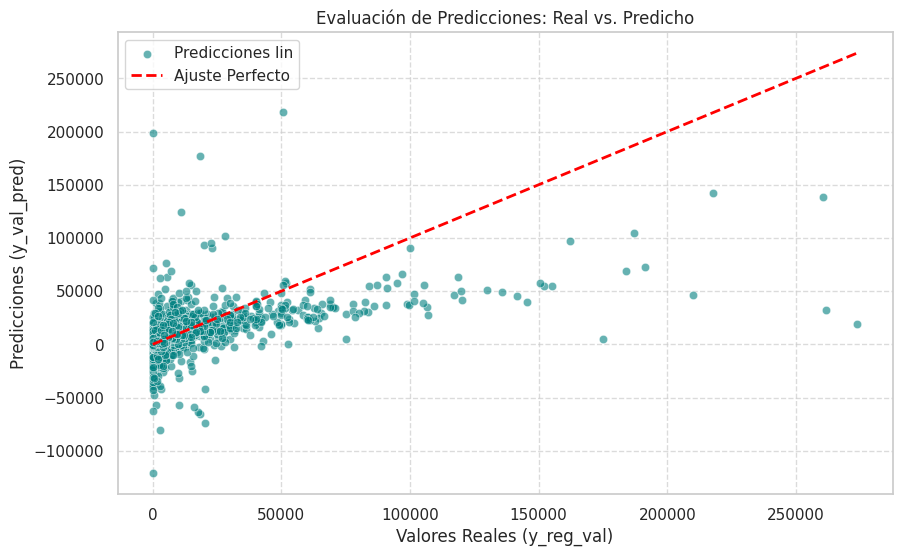

In [ ]:
# Gráfico de Dispersión (Valores Reales vs Predicciones)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_reg_val, y=y_val_pred_lin, alpha=0.6,  color='teal', label='Predicciones lin')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones lineales (y_val_pred_lin)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
pd.Series(y_val_pred_lin).describe()
# Para poder analizar a mayor detenimiento como es que se esta realizando la
# prediccion de los valores

,0
count,6000.000000
mean,5696.291465
std,10960.829923
min,-120935.959177
25%,1930.419341
50%,3702.634549
75%,7211.450296
max,218041.844235


### 4.1.2 Mejora con Support vector regression

In [ ]:
# ── 2. SUPPORT VECTOR REGRESSION
# Para poder ofrecer otra comparativa para poder analizar de manera mas rigurosa
# el modelo que se podria llegar a ajustar de mejor manera a la regresion de la
# variable PAY_AMT1, se decidio tmabien probar con el modelo de Support Vector
# Regression

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

#  Crear y Entrenar el modelo SVR
# El kernel RBF es el estándar, con los hiperparametros por defecto
svm_model = SVR(kernel="rbf")
svm_model.fit(X_train_prep, y_reg_train)

# Predicciones
y_train_pred_svm = svm_model.predict(X_train_prep)
y_val_pred_svm   = svm_model.predict(X_val_prep)

# Evaluación con RMSE (Raíz del Error Cuadrático Medio)
rmse_train_svm = np.sqrt(mean_squared_error(y_reg_train, y_train_pred_svm))
rmse_val_svm   = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_svm))

print("=== RESULTADOS SUPPORT VECTOR REGRESSION ===")
print(f"RMSE (train) SVM: {rmse_train_svm:.4f}")
print(f"RMSE (val) SVM:   {rmse_val_svm:.4f}")


=== RESULTADOS SUPPORT VECTOR REGRESSION ===
RMSE (train) SVM: 17015.2293
RMSE (val) SVM:   14287.0156


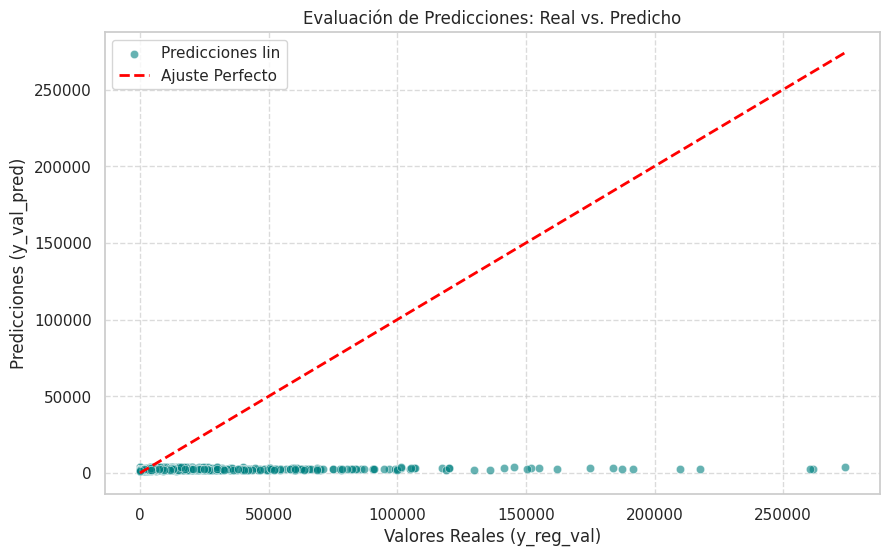

In [ ]:
# Gráfico de Dispersión (Valores Reales vs Predicciones)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_reg_val, y=y_val_pred_svm, alpha=0.6,  color='teal', label='Predicciones lin')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones (y_val_pred)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
pd.Series(y_val_pred_svm).describe()

,0
count,6000.000000
mean,2321.272169
std,601.699259
min,1517.471357
25%,1869.187634
50%,2144.469750
75%,2622.001300
max,4013.933095


El modelo de Support Vector Regression obtuvo un RMSE de 17,015 en entrenamiento y 14,287 en validación, mostrando un desempeño inferior al modelo de regresión lineal. Esto sugiere que, bajo los hiperparámetros utilizados, el modelo SVR no logra capturar adecuadamente la relación entre las variables del dataset.



Ademas cabe recalcar que el modelo de SVR puede llegar a ser mas  sensible a los outliers dentro de su entrenamiento, lo que aparte de confirmar la gran cantidad de outliers que existen, tambien nos confirma que esta caracteristica en el data set puede llegar a afectar el rendimiento de los modelos

### 4.1.3 Optimizacion de Vectores de Soporte

In [ ]:
# OPTIMIZACIÓN DE HIPERPARAMETROS Y VALIDACIÓN CRUZADA AVANZADA
# == VECTORES DE SOPORTE

from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

pasos_procesamiento = [   # Definimos la base del procesamiento
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador)
]

pipe_bosque = Pipeline(steps=pasos_procesamiento + [ ("modelo", SVR())]) #Modelo SVR

param_distributions = {
    "modelo__kernel": ["linear", "rbf"], # Definimos el espacio de búsqueda de parámetro
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__gamma": ["scale", "auto"]
}
# Configuramos la búsqueda aleatoria con Validación Cruzada (CV=5)
# Esto mitiga el sesgo de selección y optimiza al mismo tiempo
busqueda = RandomizedSearchCV(
    pipe_bosque,
    param_distributions=param_distributions,
    n_iter=10,           # Prueba 10 combinaciones aleatorias
    cv=5,                # Cada combinación se evalúa con 5-fold CV
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1            # Usa todos los procesadores para ir más rápido
)

# Entrenamos la búsqueda (Usamos X_train original porque el pipe hace el resto)
print("Ejecutando RandomizedSearchCV...")
busqueda.fit(X_train, y_reg_train)

mejor_rmse_cv = np.sqrt(-busqueda.best_score_) # Resultados

print("\n=== RESULTADOS OPTIMIZACIÓN VSR ===")
print(f"Mejor RMSE obtenido en CV: {mejor_rmse_cv:.4f}")
print("Mejores parámetros encontrados:")
print(busqueda.best_params_)

# Evaluación final sobre el set de Validación con el MEJOR modelo
mejor_modelo = busqueda.best_estimator_
y_val_pred_rf = mejor_modelo.predict(X_val)
rmse_svr_cv = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_rf))
mae_svr_cv = mean_absolute_error(y_reg_val, y_val_pred_rf)
r2_svr_cv = r2_score(y_reg_val, y_val_pred_rf)

print(f"\nRMSE Final en el set de Validación: {rmse_svr_cv:.4f}")
print(f"MAE Final en el set de Validación:  {mae_svr_cv:.4f}")
print(f"R2 Final en el set de Validación:   {r2_svr_cv:.4f}")

NameError: name 'FeatureEngineering' is not defined

In [ ]:
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

print("✅ Entorno listo. Semilla:", RANDOM_STATE)
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__)

✅ Entorno listo. Semilla: 42
Python: 3.12.12 | pandas: 2.2.2


### Tabla comparativa de modelos

## Evaluación final en el conjunto de prueba

Para la regresion Lineal

In [ ]:
# VALIDACION CRUZADA - REGRESION LINEAL
# Para tener una mejor validacion del modelo se realizo la Validacion cruzada. Asi
# logramos mitigar el riesgo de "sesgo de selección" que ocurre cuando el rendimiento
# del modelo depende de cómo se dividieron aleatoriamente los datos inicialmente
# Ademas obtenemos el RMSE promedio y su desviación estándar. Esto confirma si el
# modelo es estable (baja varianza) o si su precisión es fruto del azar en una partición específica.

from sklearn.pipeline import Pipeline

# Definimos el Pipeline de "Procesamiento Completo" (Ingeniería + Transformación)
# Este bloque prepara los datos

pasos_procesamiento = [
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador)
]

pipe_lin = Pipeline(steps=pasos_procesamiento + [# Regresión Lineal
    ('modelo', LinearRegression())
])

pipe_lin.fit(X_train, y_reg_train)  # Entrenar pipeline

y_train_pred = pipe_lin.predict(X_train) # Predicciones
y_val_pred_lin = pipe_lin.predict(X_val)

print("=== EVALUACIÓN CON PIPELINE COMPLETO ===")
rmse_lin_cv = evaluar_modelo_cv(pipe_lin, X_train, y_reg_train,  cv=5)
print(f"SVR - RMSE: {rmse_lin_cv.mean():.4f}")


=== EVALUACIÓN CON PIPELINE COMPLETO ===
SVR - RMSE: 12884.0260


### 4.1.4 LightGBM vs XGBoost

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_pipeline(pipeline, X_tr, y_tr, X_te, y_te, nombre):
    # Entrenar
    pipeline.fit(X_tr, y_tr)

    # Predecir
    y_pred = pipeline.predict(X_te)

    # Calcular Métricas
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)

    met = {
        "modelo": nombre,
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

    print(f"\n=== {nombre.upper()} REGRESIÓN ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    return met

# Definimos los modelos para Regresión
modelo_xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

modelo_lgbm_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Construimos los Pipelines de Regresión
# Construimos los Pipelines de Regresión
pipe_xgb_reg = Pipeline(steps=[("feature_eng", FeatureEngineering()), ("prep", preprocesador), ("model", modelo_xgb_reg)])

pipe_lgbm_reg = Pipeline(steps=[
    ("feature_eng", FeatureEngineering()),
    ("prep", preprocesador),
    ("model", modelo_lgbm_reg)
])

print("Pipelines construidos.")
print("Pipelines construidos.")

Pipelines construidos.
Pipelines construidos.


In [ ]:
resultados_reg = []

# Evaluar XGBoost
resultados_reg.append(evaluar_regresion(pipe_xgb_reg, X_train, y_reg_train, X_val, y_reg_val, "xgboost"))

# Evaluar LightGBM
resultados_reg.append(evaluar_regresion(pipe_lgbm_reg, X_train, y_reg_train, X_val, y_reg_val, "lightgbm"))

# Mostrar tabla comparativa (ordenada por el menor RMSE)
df_res_reg = pd.DataFrame(resultados_reg).sort_values(by="rmse")
display(df_res_reg)


=== XGBOOST REGRESIÓN ===
RMSE: 5604.8768
MAE:  1631.3102
R2:   0.8405
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005549 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 25
[LightGBM] [Info] Start training from score 5645.855778

=== LIGHTGBM REGRESIÓN ===
RMSE: 6174.5878
MAE:  1851.2309
R2:   0.8064


,modelo,rmse,mae,r2
0,xgboost,5604.876805,1631.310181,0.840499
1,lightgbm,6174.587847,1851.230915,0.806426


### Tabla comparativa

In [ ]:

resultados = []

metricas_lin = {
    "modelo": "Linear",
    "rmse": float(rmse_lin_cv.mean())  # El error de la validación simple
}
resultados.append(metricas_lin)

metricas_reg = {
    "modelo": "SVR",
    "rmse": float(rmse_svr_cv) # El promedio de la validación cruzada
}

resultados.append(metricas_reg)


resultados.append(evaluar_pipeline(pipe_xgb_reg, X_train, y_reg_train, X_test, y_reg_test, "xgboost"))
resultados.append(evaluar_pipeline(pipe_lgbm_reg, X_train, y_reg_train, X_test, y_reg_test, "lightgbm"))

resultados = pd.DataFrame(resultados).sort_values(by="rmse", ascending=False).reset_index(drop=True)
display(resultados)


=== XGBOOST REGRESIÓN ===
RMSE: 14676.4759
MAE:  2067.8040
R2:   0.3445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 25
[LightGBM] [Info] Start training from score 5645.855778

=== LIGHTGBM REGRESIÓN ===
RMSE: 9042.4762
MAE:  2166.7322
R2:   0.7512


,modelo,rmse,mae,r2
0,xgboost,14676.475871,2067.803955,0.344504
1,SVR,12965.479678,NaN,NaN
2,Linear,12884.025981,NaN,NaN
3,lightgbm,9042.476249,2166.732177,0.751171


### Validacion cruzada

In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}
def resumen_cv(pipeline, X_data, y_data, nombre):

    res = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    return {
        "modelo": nombre,
        "rmse_mean": float(-np.mean(res["test_rmse"])),
        "rmse_std": float(np.std(res["test_rmse"])),
        "mae_mean": float(-np.mean(res["test_mae"])),
        "mae_std": float(np.std(res["test_mae"])),
        "r2_mean": float(np.mean(res["test_r2"])),
        "r2_std": float(np.std(res["test_r2"]))
    }

df_cv = pd.DataFrame([
    resumen_cv(pipe_xgb_reg, X, y_reg, "xgboost"),
    resumen_cv(pipe_lgbm_reg, X, y_reg, "lightgbm")
]).sort_values(by="rmse_mean").reset_index(drop=True)

display(df_cv)

,modelo,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,lightgbm,8394.524815,2033.418466,1933.134223,47.528549,0.740772,0.043729
1,xgboost,9113.362305,2495.696537,1703.651416,25.822073,0.662931,0.196097


### Tuning

In [ ]:
mejor_nombre = df_cv.iloc[0]["modelo"]
print("Mejor modelo por RMSE (CV):", mejor_nombre)

pipelines = {
    "xgboost": pipe_xgb_reg,
    "lightgbm": pipe_lgbm_reg
}

pipeline_mejor = pipelines[mejor_nombre]

if mejor_nombre == "xgboost":
    param_distributions = {
        "model__n_estimators": [300, 500, 800],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [4, 6, 8],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

elif mejor_nombre == "lightgbm":
    param_distributions = {
        "model__n_estimators": [400, 700, 1000],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__num_leaves": [31, 63, 127],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

buscador = RandomizedSearchCV(
    estimator=pipeline_mejor,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

buscador.fit(X_train, y_reg_train)

print("✅ Búsqueda completada.")
print("Mejores hiperparámetros:\n", buscador.best_params_)

print("Mejor RMSE (CV):", -buscador.best_score_)

## REsumen metricas finales

In [ ]:
mejor_pipeline_ajustado = buscador.best_estimator_
metricas_finales = evaluar_pipeline(
    mejor_pipeline_ajustado, X_train, y_train, X_test, y_test,
    nombre=f"{mejor_nombre}_ajustado"
)

display(pd.DataFrame([metricas_finales]))